# 📓 Cas d'usage IA — Campagne de marketing bancaire

**Auteur** : Franck Walter  
**Promo** : Dev-id — Parcours 2 (Pros IT)  
**Date début** : 07/09/2026  
**Dernière mise à jour** : `JJ/MM/AAAA`

## 0. Imports & configuration

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins
DATA_DIR = Path("data")

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Imports ML (à activer au fur et à mesure)
# from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

## 0.5 Traçabilité de la session

🎯 Documenter ce qui rend l'analyse **reproductible** par toi (sur un autre poste) ou par un collègue qui reprendrait le notebook dans 3 mois.

💡 Trois choses à figer :
- la **version du dataset** (source, date d'extraction, hash si possible),
- les **versions des libs** (cf. `requirements.txt` du repo associé, ou `pip freeze`),
- le **commit Git** du repo associé au notebook.

⚠️ Sans ces 3 éléments, ton analyse n'est pas reproductible. C'est un attendu pro fort, et c'est noté en certif.

In [2]:
import sys
import hashlib
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "UCI Bank Marketing — bank-additional-full.csv"
DATASET_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing"
DATASET_VERSION = "2012-02-13"   # date de dépôt sur UCI, le contenu ne bouge plus depuis
DATASET_RECEIVED = "2026-07-23"  # date de réception du fichier fourni par Simplon
DATASET_PATH = DATA_DIR / "bank-additional-full.csv"

dataset_hash = hashlib.sha256(DATASET_PATH.read_bytes()).hexdigest()[:12]

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME}")
print(f"  source     : {DATASET_SOURCE}")
print(f"  version    : {DATASET_VERSION} (reçu le {DATASET_RECEIVED})")
print(f"  sha256     : {dataset_hash}")

Date session : 2026-09-24T22:34
Python       : 3.12.9
NumPy        : 2.5.3
Pandas       : 3.0.5
Git commit   : dbb3f29
Dataset      : UCI Bank Marketing — bank-additional-full.csv
  source     : https://archive.ics.uci.edu/dataset/222/bank+marketing
  version    : 2012-02-13 (reçu le 2026-07-23)
  sha256     : 233e260d5d1d


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une banque de détail portugaise, dont le besoin est de faire souscrire à ses clients des contrats pour des produits d'épargne, en particulier un dépôt à terme. Cela rentre dans l'activité commerciale normale dans le secteur bancaire, à savoir vendre le plus possible de produits aux clients afin d'augmenter le chiffre d'affaires et donc les profits de l'entreprise.

D'après les données fournies, seuls 11% des clients souscrivent à un contrat suite à un appel de la banque, et les campagnes de démarchage téléphonique ont un coût, financier et en termes de dégradation de la relation commerciale. De même, les capacités d'appels de la banque sont limitées par le nombre de conseillers et la durée de la campagne, ce qui empêche d'appeler l'ensemble des clients. C'est pourquoi un ciblage des clients les plus susceptibles de souscrire au contrat est justifié, plutôt que de démarcher tous les clients.

C'est dans ce contexte qu'un recours à l'intelligence artificielle est demandé, afin d'augmenter le retour sur investissement de la campagne marketing, soit en obtenant davantage de souscriptions pour un nombre d'appels donné, soit en réduisant le nombre d'appels nécessaires.


### 1.2 Énoncé du problème IA

Il s'agit de prédire quels clients sont les plus susceptibles de souscrire un contrat pour un produit d'épargne. Il s'agit donc d'une classification en deux catégories, oui il va souscrire ou non il ne va pas souscrire.

Pour cela, les données utilisées sont :
- des données socio-démographiques du client
- la situation bancaire du client
- des informations sur le dernier contact de la campagne en cours
- un historique de la campagne
- le context socio-économique

### 1.3 Bénéficiaires & impacts

Le bénéficiaire direct de la solution est la banque, qui augmente son chiffre d'affaires en vendant des produits d'épargne.
Un client qui a souscrit un produit d'épargne peut être un bénéficiaire indirect si on considère qu'il tire des bénéfices de ce produit d'épargne, ou que le produit répond à un besoin de ce client.

En revanche, les clients peuvent subir un impact négatif si la campagne les incite à souscrire à un produit dont ils n'ont pas besoin ou qui va les impacter négativement, par exemple leur causer des pertes financières.


### 1.4 Critères de succès

⚠️ La cible **avant EDA** est ce que demande le client. La cible **révisée après EDA** tient compte des contraintes réelles de la donnée. Les deux doivent apparaître.

| | Métier | Modèle | Opérationnel |
|---|---|---|---|
| **Critère** | Réduire le nombre de clients contactés tout en préservant les souscriptions | Rappel (recall) de la classe « oui », sous contrainte de volume de clients sélectionnés | Temps de réponse de l'API (p95) |
| **Cible initiale** | Contacter 50 % de clients en moins en conservant au moins 80 % des souscriptions | Rappel (recall) ≥ 0,80 en sélectionnant au maximum 50 % des clients | < 200 ms |
| **Pourquoi cette cible** | Réduire le coût des appels et les sollicitations inutiles, tout en limitant les ventes perdues | Limiter les souscripteurs manqués, sans atteindre artificiellement un bon rappel (recall) en sélectionnant tous les clients | Une réponse quasi instantanée permet au conseiller de préparer son appel sans attendre. Ce temps de réponse permet également de traiter un fichier de plusieurs milliers de clients en quelques heures. |
| **Cible révisée** | *[après §5]* | *[après §5]* | *[après §5]* |
| **Pourquoi la révision** | *[ex: cible irréaliste vu le déséquilibre des classes]* | *[…]* | *[…]* |

### 1.5 Risques éthiques & réglementaires anticipés

**Variables sensibles** : âge, profession, situation familiale et niveau d’éducation, susceptibles d’entraîner un ciblage discriminatoire  
**Biais possibles** : les campagnes passées peuvent contenir des biais que le modèle risque de reproduire, en favorisant ou en excluant certains profils  
**RGPD** : vérifier les conditions d’utilisation des données personnelles pour le ciblage, leur minimisation et le respect des droits des clients.  
**AI Act** : déterminer la classification du système et les obligations applicables à une campagne marketing pour un produit bancaire  
**Droit sectoriel** : vérifier les règles applicables au démarchage téléphonique et à la commercialisation de produits d’épargne au Portugal.  
**Transparence** : les conseillers devront pouvoir comprendre les recommandations du modèle et garder la maîtrise du choix des clients à contacter.  
**Pression commerciale** : des sollicitations répétées ou inadaptées pourraient dégrader la relation client ou encourager une souscription qui ne répond pas à ses besoins.  


### 1.6 📝 Synthèse cadrage

La banque souhaite mieux cibler ses campagnes téléphoniques pour réduire leur coût et les sollicitations inutiles tout en préservant les souscriptions.  
La solution envisagée est un modèle de classification binaire prédisant la souscription à un produit d’épargne à partir des données clients et de campagne.  
L’objectif initial est de contacter 50 % de clients en moins en conservant au moins 80 % des souscriptions, soit un rappel (recall) ≥ 0,80 en sélectionnant au maximum 50 % des clients.  
Le principal risque éthique est de reproduire les biais des campagnes passées et de créer un ciblage discriminatoire ; l’utilisation des données et les pratiques commerciales devront aussi être examinées au regard du cadre réglementaire applicable.


---
## 2. Identification & acquisition des données



### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Bank Marketing, University of California, Irvine (UCI), fichier fourni par Simplon | Données tabulaires de campagnes de marketing bancaire | 41 188 lignes et 21 colonnes (20 variables explicatives + la cible `y`) | CSV, séparateur `;` | Fichier local : `data/bank-additional-full.csv` | Extraction non renseignée ; réception le 23/07/2026 |


In [3]:
# 2.2 Chargement
df = pd.read_csv(DATASET_PATH, sep=";")
df.shape, df.columns.tolist()

((41188, 21),
 ['age',
  'job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'poutcome',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed',
  'y'])

### 2.3 Dictionnaire de variables

À partir du sujet d'examen et de la [source UCI](https://archive.ics.uci.edu/dataset/222/bank+marketing).



| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `age` | Âge du client | Numérique | De 17 à 98 ans | × | ✅ |
| `job` | Type d’emploi du client | Catégoriel sans ordre | - `admin.` : employé administratif<br>- `blue-collar` : ouvrier<br>- `entrepreneur` : entrepreneur<br>- `housemaid` : employé de maison<br>- `management` : cadre / dirigeant<br>- `retired` : retraité<br>- `self-employed` : travailleur indépendant<br>- `services` : employé des services<br>- `student` : étudiant<br>- `technician` : technicien<br>- `unemployed` : sans emploi<br>- `unknown` : inconnu | × | ✅ |
| `marital` | Statut marital du client | Catégoriel sans ordre | - `married` : marié<br>- `single` : célibataire<br>- `divorced` : divorcé (inclut les personnes veuves)<br>- `unknown` : inconnu | × | ✅ |
| `education` | Niveau d’éducation | Catégoriel partiellement ordonné (`professional.course` difficile à situer ; `unknown` sans rang) | - `basic.4y` : enseignement de base, 4 ans<br>- `basic.6y` : enseignement de base, 6 ans<br>- `basic.9y` : enseignement de base, 9 ans<br>- `high.school` : enseignement secondaire<br>- `illiterate` : analphabète<br>- `professional.course` : formation professionnelle<br>- `university.degree` : diplôme universitaire<br>- `unknown` : inconnu | × | ✅ |
| `default` | Le client a-t-il un crédit en défaut de paiement ? | Catégoriel sans ordre | - `yes` : oui<br>- `no` : non<br>- `unknown` : inconnu | × | × |
| `housing` | Le client a-t-il un prêt immobilier ? | Catégoriel sans ordre | - `yes` : oui<br>- `no` : non<br>- `unknown` : inconnu | × | × |
| `loan` | Le client a-t-il un prêt personnel ? | Catégoriel sans ordre | - `yes` : oui<br>- `no` : non<br>- `unknown` : inconnu | × | × |
| `contact` | Type de moyen de contact du dernier contact de la campagne en cours | Catégoriel sans ordre | - `cellular` : téléphone mobile<br>- `telephone` : téléphone fixe | × | × |
| `month` | Mois du dernier contact de l’année pour la campagne en cours | Catégoriel cyclique | - `mar` : mars<br>- `apr` : avril<br>- `may` : mai<br>- `jun` : juin<br>- `jul` : juillet<br>- `aug` : août<br>- `sep` : septembre<br>- `oct` : octobre<br>- `nov` : novembre<br>- `dec` : décembre | × | × |
| `day_of_week` | Jour de la semaine du dernier contact de la campagne en cours | Catégoriel cyclique | - `mon` : lundi<br>- `tue` : mardi<br>- `wed` : mercredi<br>- `thu` : jeudi<br>- `fri` : vendredi | × | × |
| `duration` | Durée du dernier contact, en secondes, dans la campagne en cours | Numérique | De 0 à 4 918 secondes | × | × |
| `campaign` | Nombre de contacts effectués durant cette campagne pour ce client, incluant le dernier contact | Numérique | De 1 à 56 contacts | × | × |
| `pdays` | Nombre de jours écoulés depuis le dernier contact d’une campagne précédente | Numérique | - De 0 à 27 jours<br>- `999` signifie que le client n’a jamais été contacté auparavant | × | × |
| `previous` | Nombre de contacts effectués avant cette campagne pour ce client | Numérique (entier) | De 0 à 7 contacts | × | × |
| `poutcome` | Résultat de la campagne marketing précédente | Catégoriel sans ordre | - `failure` : échec<br>- `nonexistent` : absence de campagne précédente pour ce client<br>- `success` : succès | × | × |
| `emp.var.rate` | Taux de variation de l’emploi, indicateur trimestriel | Numérique | De -3,4 à 1,4 | × | × |
| `cons.price.idx` | Indice des prix à la consommation, indicateur mensuel | Numérique | De 92,201 à 94,767 | × | × |
| `cons.conf.idx` | Indice de confiance des consommateurs, indicateur mensuel | Numérique | De -50,8 à -26,9 | × | × |
| `euribor3m` | Taux Euribor à 3 mois, indicateur journalier | Numérique | De 0,634 à 5,045 | × | × |
| `nr.employed` | Nombre de salariés, indicateur trimestriel | Numérique | De 4 963,6 à 5 228,1 | × | × |
| `y` | Le client a-t-il souscrit un dépôt à terme ? | Binaire | - `yes` : oui<br>- `no` : non | ✅ | × |



### 2.4 📝 Synthèse acquisition

ORIGINE DES DONNÉES
- jeu de données UCI Bank Marketing
- fichier fourni par Simplon
- stocké localement dans `data/bank-additional-full.csv`

STRUCTURE DES DONNÉES
- jeu de données tabulaire composé de variables numériques, catégorielles et d’une cible binaire ;
- 41 188 lignes et 21 colonnes (y compris la cible)
- les variables sont nommées et décrivent le profil client, des données sur la campagne en cours et des campgnes précédentes, ainsi que données qui ne sont pas liées directement au client (le contexte économique)

PAS DE VALEUR MANQUANTE DIRECTE
- aucune valeur manquante, toutes les colonnes sont complètes

DES VALEURS INCONNUES
- des données qui pourraient être binaires mais qui ont une valeur `unknown` : `default` (20,87 %), `housing` (2,40 %) et `loan` (2,40 %)
- `poutcome` pourrait être binaire (`failure` / `success`), mais comporte une troisième modalité `nonexistent` lorsque le client n’a pas été contacté lors d’une campagne précédente
- les variables catégorielles `job`, `marital` et `education` comportent également une modalité `unknown` : `job` (0,80 %), `marital` (0,19 %) et `education` (4,20 %)
- pour la variable numérique `pdays` (nombre de jours écoulés depuis le dernier contact d'une campagne précédente), une valeur extrême utilisée pour signifier « jamais recontacté », à vérifeir par la suite si cette valeur pour fausser le modèle et s'il faut l'exclure ou la remplacer

UNE FUITE D'INFORMATION
- `duration` constitue une fuite d’information certaine : la durée de l’appel n’est connue qu’après celui-ci, alors que le modèle doit décider quels clients appeler avant le début de l’appel
- les variables `campaign`, `contact`, `month` et `day_of_week` décrivent aussi la campagne en cours. Leur utilisation dépend du moment où la décision de ciblage est prise et des informations réellement disponibles à ce moment-là. Il faudra donc clarifier le processus métier avant de les inclure dans le modèle
- les variables `pdays`, `previous` et `poutcome` décrivent les campagnes précédentes et peuvent a priori être connues avant un nouvel appel

DES VARIABLES SENSIBLES
- les personnelles des clients (son âge, son type d'emploi, son statut marital, son niveau d'éducation)





---
## 3. Exploration & analyse des données (EDA)

**Compétences** : C2 (risques éthiques détectables dans la donnée), C3 (préparation des données)

🎯 Comprendre la donnée **avant** de la transformer. Détecter manquants, doublons, aberrations, déséquilibres, biais.

⚠️ EDA ≠ catalogue de graphiques. Chaque visualisation doit servir une question.

In [4]:
# 3.1 Premier coup d'œil
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()
# int64 (5) : age, duration, campaign, pdays, previous
# float64 (5) : emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
# str (11) : job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
print(df.describe(include="all"))
print(f"campaign > 10   : {(df['campaign']>10).mean()*100:.1f} %")
print(f"campaign == max : {(df['campaign']==df['campaign'].max()).sum()} ligne(s)")
print(f"pdays == 999    : {(df['pdays']==999).mean()*100:.1f} %")
print(f"previous == 0   : {(df['previous']==0).mean()*100:.1f} %")
print(df.nunique())
print(f"y == 'no'       : {(df['y']=='no').mean()*100:.1f} %")

# age : moyenne 40,0 proche de la médiane 38, rien à signaler
# duration : moyenne 258 >> médiane 180, max 4918 loin du Q3 (319), quelques appels très longs tirent la moyenne vers le haut ; à croiser avec y pour vérifier la fuite de données
# campaign : max 56 mais une seule ligne à cette valeur, 2,1 % > 10 contacts, à vérifier si erreur de saisie
# pdays : 96,3 % valent 999 ("jamais contacté avant"), seuls les 3,7 % restants ont une valeur réelle
# previous : 86,3 % ont la valeur 0, la grande majorité des clients n'ont jamais été contactés avant cette campagne
# emp.var.rate, cons.price.idx, cons.conf.idx, nr.employed : peu de valeurs distinctes (10, 26, 26, 11), se comportent davantage comme des catégorielles ordonnées que comme des valeurs continues
# euribor3m : 316 valeurs distinctes, plus variées que les autres indicateurs
# y : 88,7 % de "no" — cible déséquilibrée (11,3 % de "yes")

                age     job  marital          education default housing  \
count   41188.00000   41188    41188              41188   41188   41188   
unique          NaN      12        4                  8       3       3   
top             NaN  admin.  married  university.degree      no     yes   
freq            NaN   10422    24928              12168   32588   21576   
mean       40.02406     NaN      NaN                NaN     NaN     NaN   
std        10.42125     NaN      NaN                NaN     NaN     NaN   
min        17.00000     NaN      NaN                NaN     NaN     NaN   
25%        32.00000     NaN      NaN                NaN     NaN     NaN   
50%        38.00000     NaN      NaN                NaN     NaN     NaN   
75%        47.00000     NaN      NaN                NaN     NaN     NaN   
max        98.00000     NaN      NaN                NaN     NaN     NaN   

         loan   contact  month day_of_week      duration      campaign  \
count   41188     41188  

In [7]:
# 3.2 Qualité des données : manquants, doublons, valeurs aberrantes

## MANQUANTS
print(df.isna().sum())
# aucune valeur manquante, toutes les colonnes sont à 0

## DOUBLONS
print(f"Doublons : {df.duplicated().sum()}")
# 12 lignes entièrement identiques à une autre ligne du dataset, donc il faudra déboulonner avant l'utilisation des données
print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))
# 12 paires de lignes identiques (indices) : 1265-1266, 12260-12261, 14155-14234, 16819-16956, 18464-18465, 20072-20216, 20531-20534, 25183-25217, 28476-28477, 32505-32516, 36950-36951, 38255-38281

# VALEURS ABERRANTES
# pdays : 96,3 % des valeurs sont à 999, code conventionnel signifiant que le client n’a pas été contacté auparavant.
# campaign : maximum de 56 contacts sur une seule ligne ; 2,1 % des observations dépassent 10 contacts.
# duration : maximum de 4 918 secondes, avec une moyenne de 258 secondes et une médiane de 180 secondes.
# age : les âges vont de 17 à 98 ans.
# Ces valeurs extrêmes paraissent plausibles et ne sont pas nécessairement des erreurs de saisie.

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Doublons : 12
       age          job   marital            education  default housing loan  \
28476   24     services    single          high.school       no     yes   no   
28477   24     services    single          high.school       no     yes   no   
14155   27   technician    single  professional.course       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
18464   32   technician    single  professional.course       no     yes   no   
18465   32   technician    single  professional.course       no     yes  

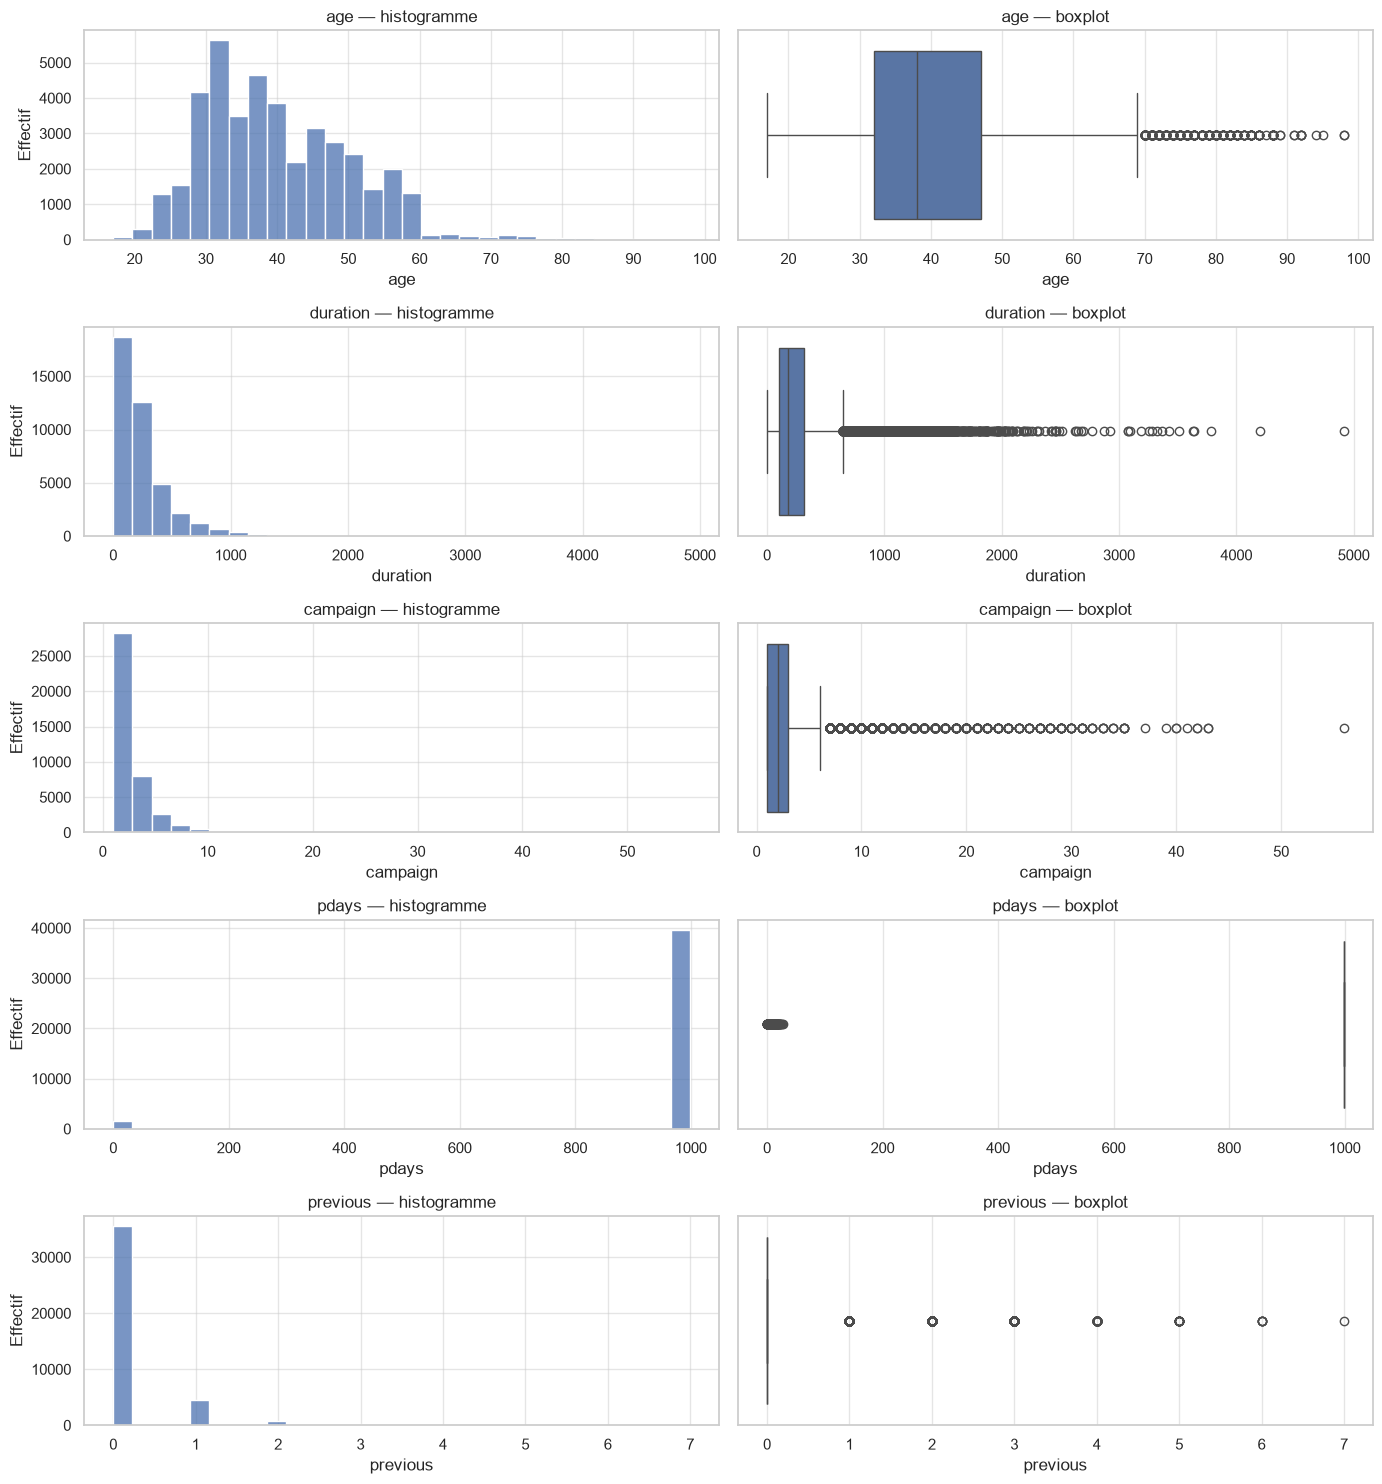

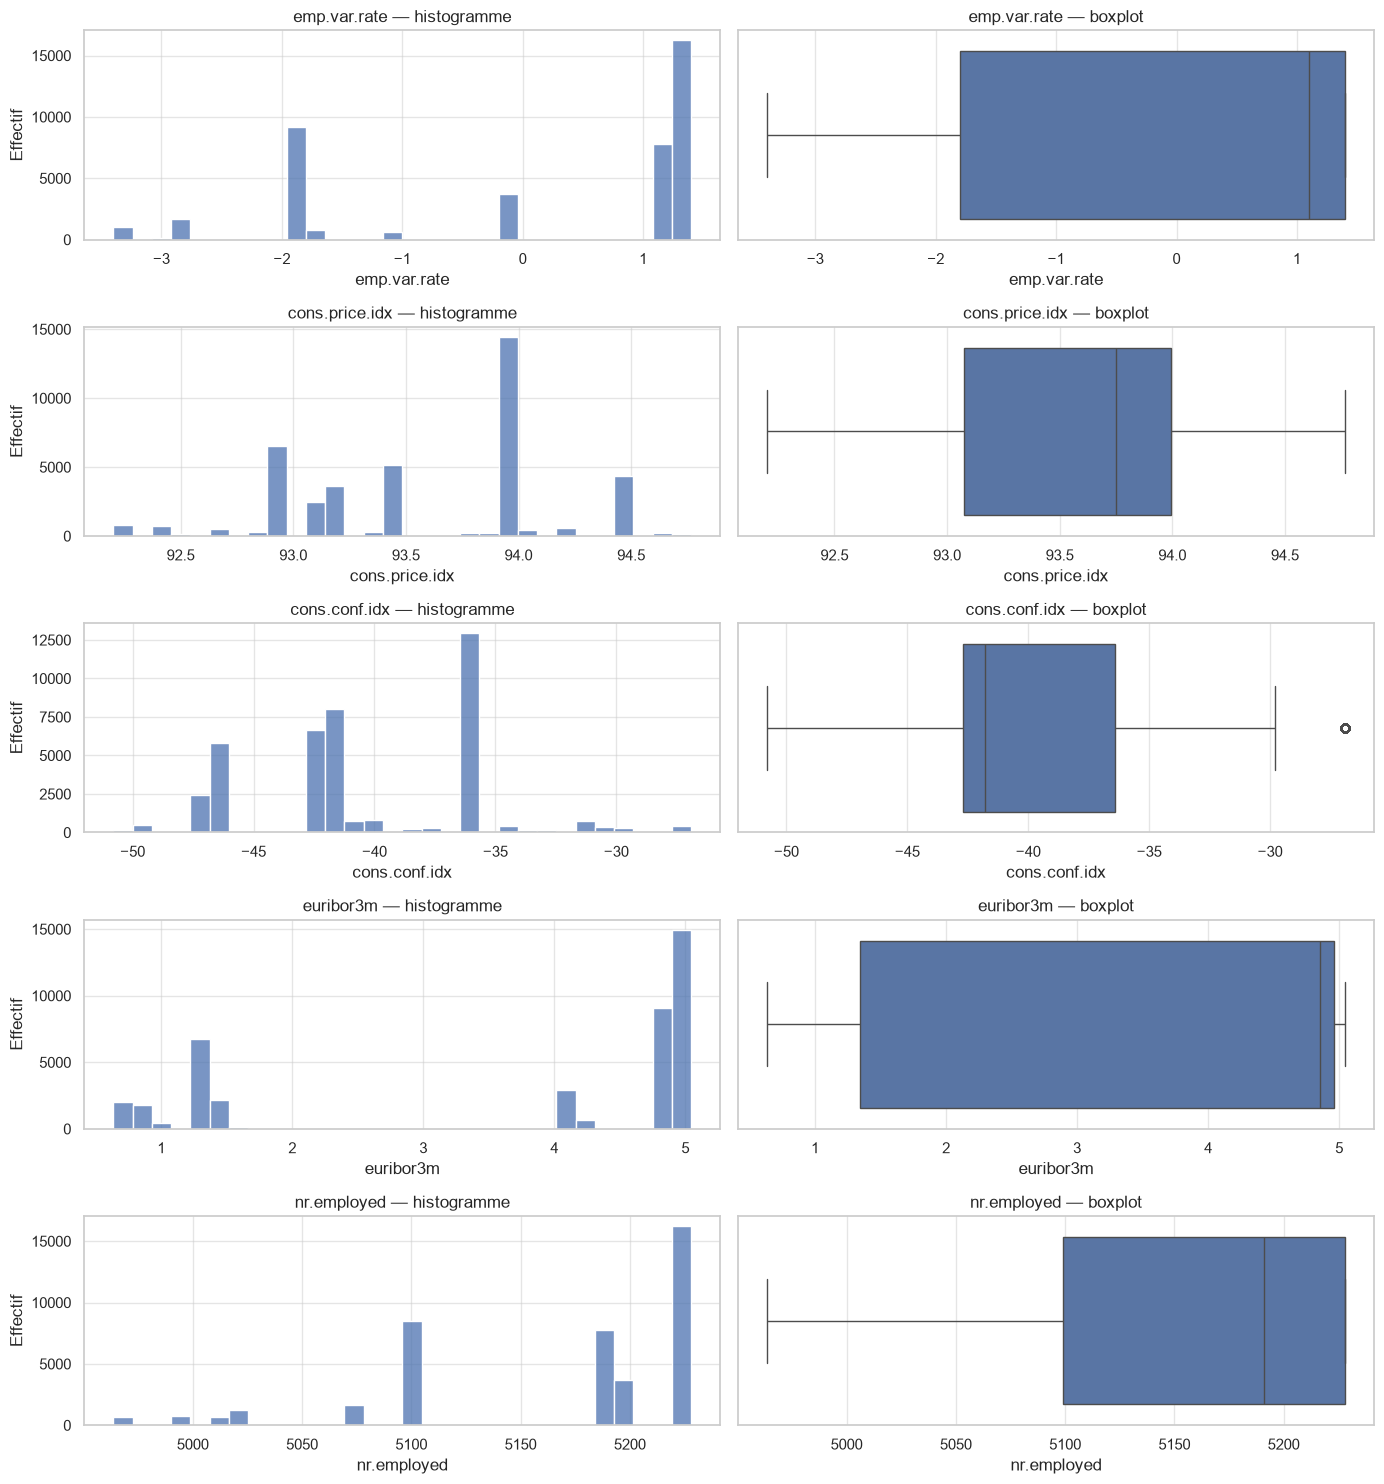

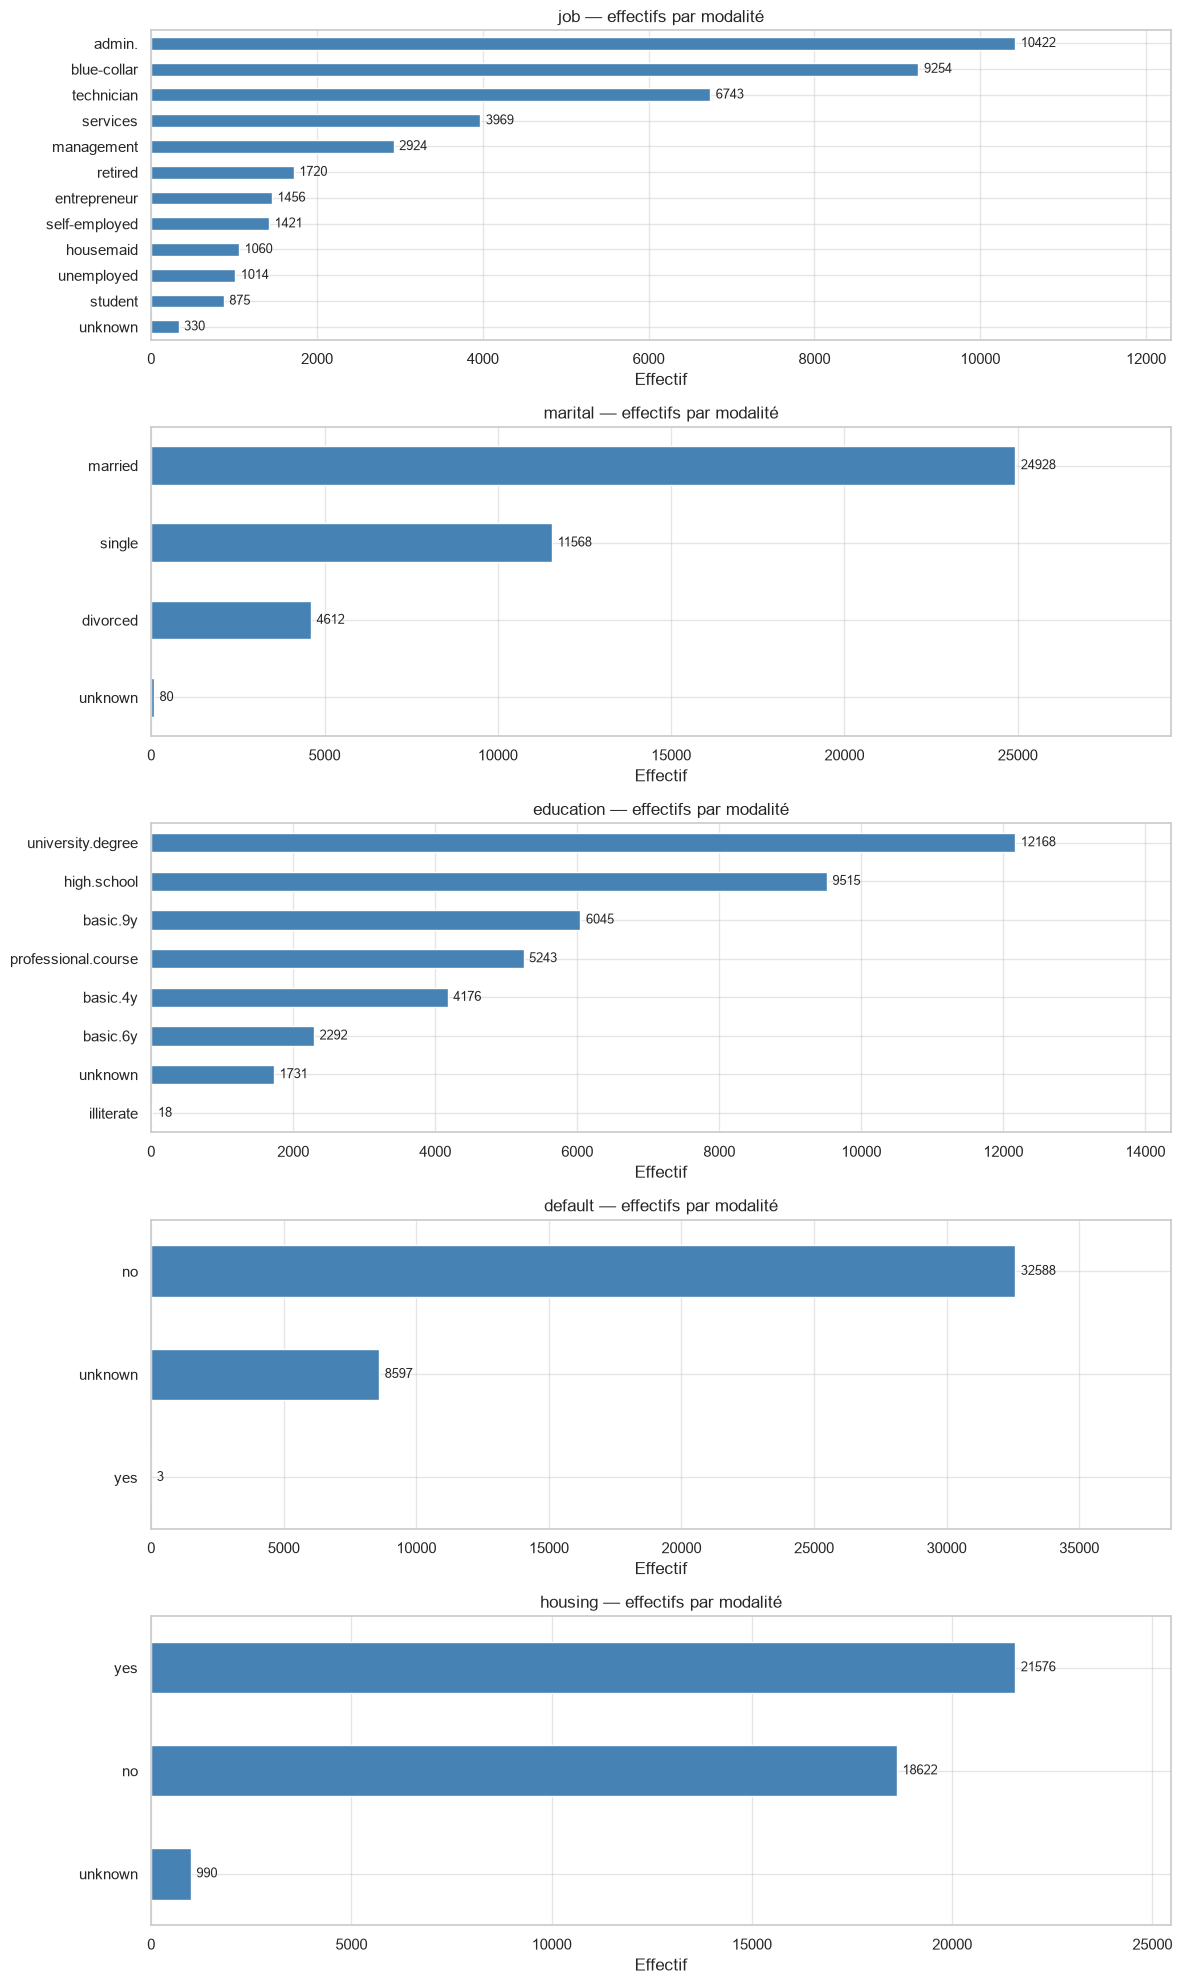

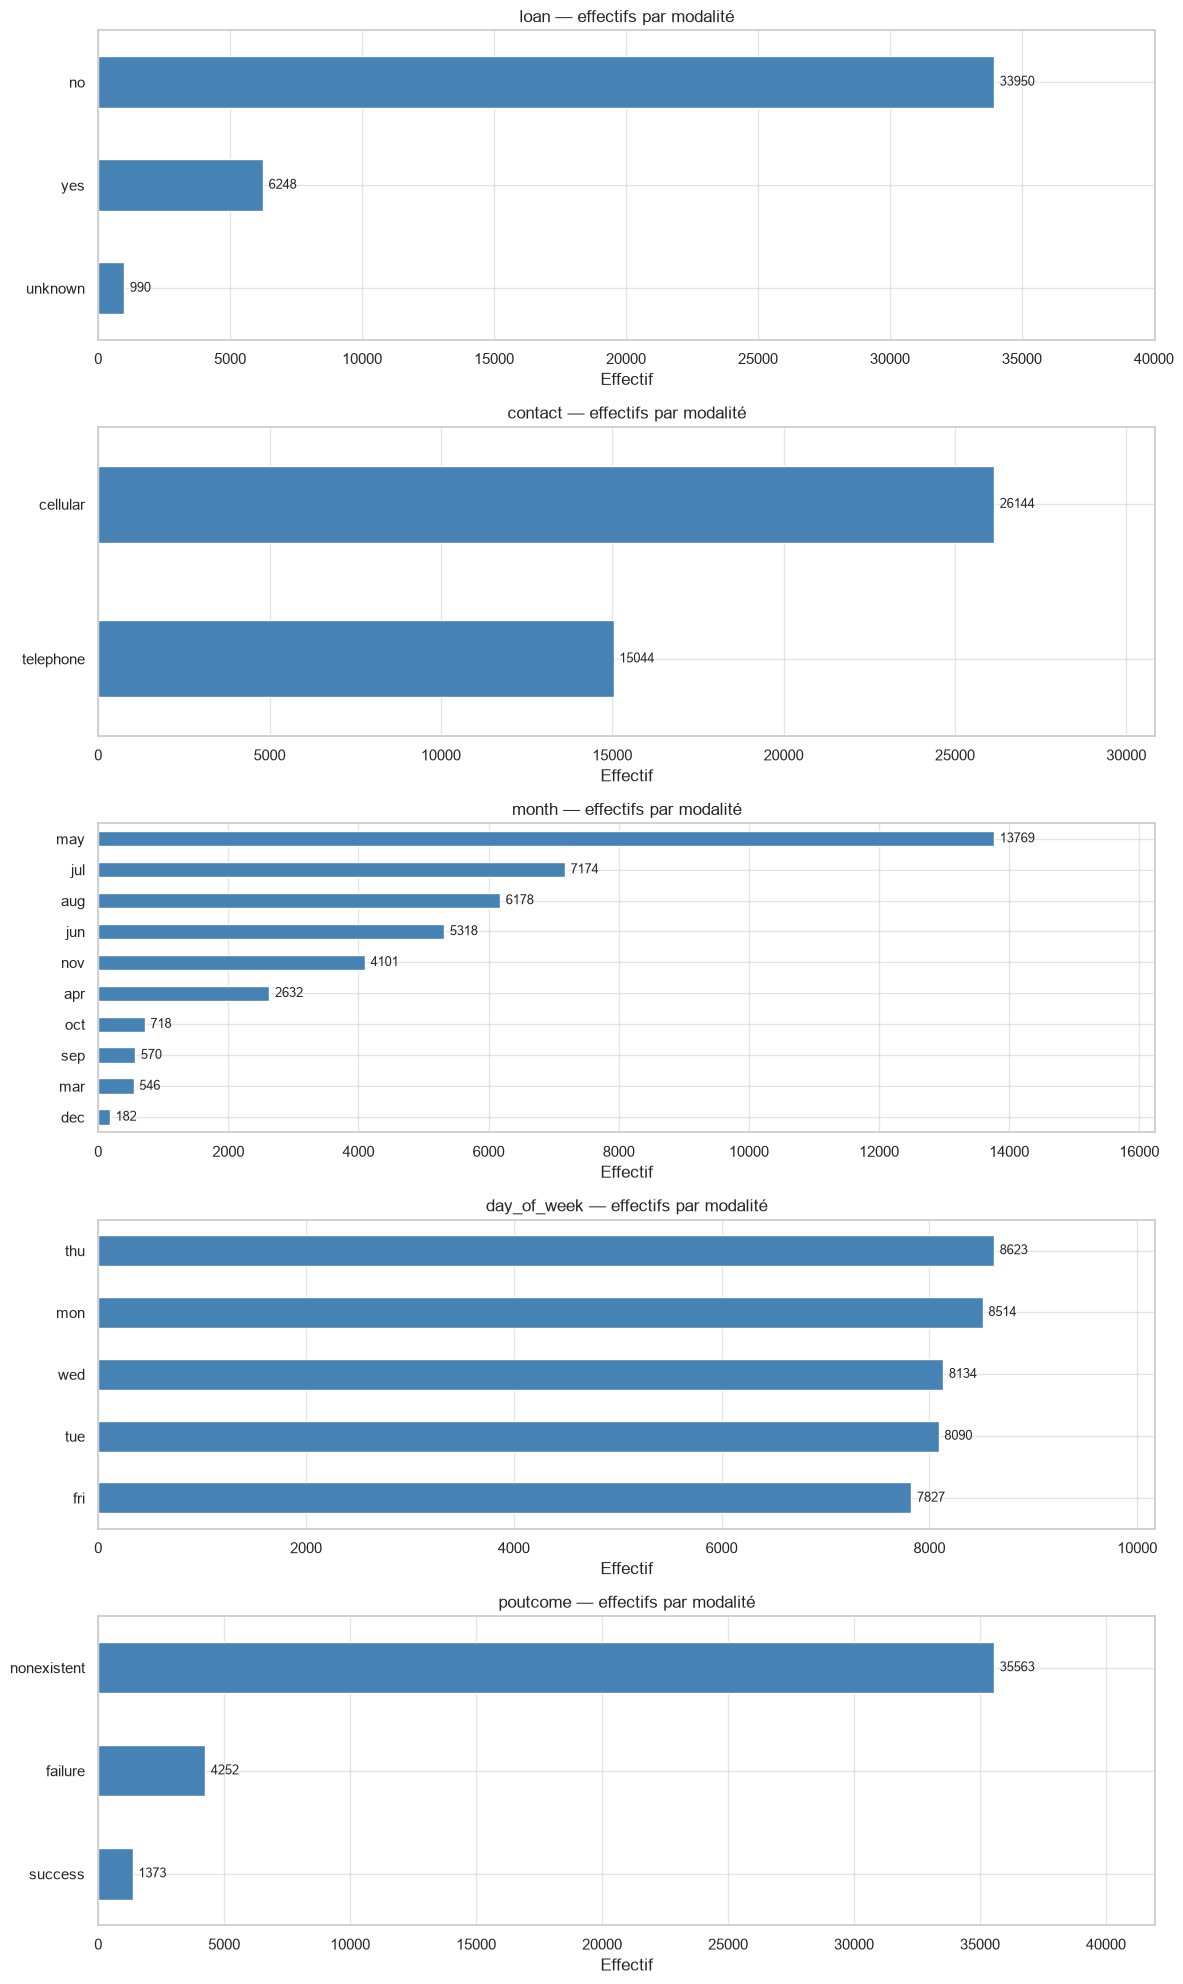

In [8]:
# 3.3 Distribution des variables (numériques + catégorielles)
# Histogrammes, boxplots, value_counts

variables_numeriques = df.select_dtypes(include="number").columns
variables_categorielles = df.drop(columns="y").select_dtypes(exclude="number").columns

for debut in range(0, len(variables_numeriques), 5):
    groupe = variables_numeriques[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 2, figsize=(14, 3 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        sns.histplot(data=df, x=variable, bins=30, ax=axes[ligne, 0])
        axes[ligne, 0].set_title(f"{variable} — histogramme")
        axes[ligne, 0].set_ylabel("Effectif")
        sns.boxplot(data=df, x=variable, ax=axes[ligne, 1])
        axes[ligne, 1].set_title(f"{variable} — boxplot")
    fig.tight_layout()
    plt.show()

for debut in range(0, len(variables_categorielles), 5):
    groupe = variables_categorielles[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 1, figsize=(12, 4 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        effectifs = df[variable].value_counts(dropna=False)
        ax = axes[ligne, 0]
        effectifs.iloc[::-1].plot.barh(ax=ax, color="steelblue")
        ax.set_title(f"{variable} — effectifs par modalité")
        ax.set_xlabel("Effectif")
        ax.set_ylabel("")
        ax.bar_label(ax.containers[0], padding=4, fontsize=9)
        ax.set_xlim(0, effectifs.max() * 1.18)
    fig.tight_layout()
    plt.show()


- `age` : les âges paraissent plausibles, avec une concentration chez les adultes jeunes ou d’âge moyen et des personnes âgées moins représentées.
- `duration` : les appels sont généralement courts, avec quelques durées extrêmes déjà relevées ; 3 000 à 4 000 secondes représentent 50 minutes à 1 h 07 et le maximum atteint environ 1 h 22, ce qui reste plausible.
- `campaign` : les clients ont généralement été contactés peu de fois, surtout une fois, mais les valeurs de 30 à 40 contacts et le maximum de 56 paraissent suspects et restent à vérifier.
- `pdays` : la valeur conventionnelle 999 domine et écrase la distribution des délais réels sur les graphiques.
- `previous` : la valeur 0 domine, avec quelques observations réparties entre 1 et 7 contacts antérieurs, ce qui paraît plausible.
- `emp.var.rate` : les valeurs se situent entre −3,4 et 1,4 et paraissent plausibles pour cet indicateur économique.
- `cons.price.idx` : les valeurs se situent entre 92,201 et 94,767 et paraissent plausibles pour cet indice.
- `cons.conf.idx` : les valeurs se situent entre −50,8 et −26,9 ; la valeur −26,9 apparaît isolée sur le boxplot, sans constituer à elle seule une erreur.
- `euribor3m` : les valeurs se situent entre 0,634 et 5,045 et paraissent plausibles pour ce taux.
- `nr.employed` : les valeurs se situent entre 4 963,6 et 5 228,1 et paraissent plausibles pour cet indicateur.
- `job` : les employés administratifs, ouvriers et techniciens sont les catégories les plus représentées ; les 330 `unknown` restent à traiter, avec un éventuel regroupement à justifier.
- `marital` : les personnes mariées dominent, suivies des célibataires ; les 80 `unknown` restent à traiter, avec un éventuel regroupement à justifier.
- `education` : `university.degree` et `high.school` sont les modalités les plus représentées séparément, mais les trois niveaux `basic` totalisent 12 513 personnes, ou 17 756 avec `professional.course`, et 1 731 valeurs sont `unknown`.
- `default` : les 8 597 `unknown` et les seuls 3 `yes` interrogent l’utilité de la variable et le risque d’apprendre une association fragile avec la souscription ; son maintien sera à évaluer.
- `housing` : les modalités `yes` et `no` sont assez équilibrées, avec 990 `unknown`.
- `loan` : les `no` dominent, les `yes` restent bien représentés et les 990 `unknown` invitent à vérifier s’il s’agit des mêmes lignes que pour `housing`.
- `contact` : les contacts par téléphone mobile dominent, avec une part de téléphone fixe qui reste représentée.
- `month` : la répartition reflète le calendrier des campagnes ; l’utilité de cette variable et sa pertinence pour une campagne menée à un autre moment de l’année restent à évaluer.
- `day_of_week` : la répartition est assez uniforme et l’apport prédictif du jour reste à vérifier.
- `poutcome` : `nonexistent` domine et indique l’absence de campagne précédente pour beaucoup de clients ; sa cohérence avec `previous` et `pdays` reste à vérifier.

À vérifier : les `unknown` concernent-ils les mêmes lignes, et certaines lignes cumulent-elles assez de variables inconnues pour envisager leur suppression ?


In [9]:
# 3.3 — Vérification des valeurs unknown communes
colonnes_unknown = [col for col in df.columns if df[col].eq("unknown").any()]
masque_unknown = df[colonnes_unknown].eq("unknown")
print("Nombre de unknown par variable :")
print(masque_unknown.sum().to_string())
print("\nCroisement housing / loan (True = unknown) :")
print(pd.crosstab(masque_unknown["housing"], masque_unknown["loan"]).to_string())
print("Mêmes lignes unknown pour housing et loan :",
      masque_unknown["housing"].equals(masque_unknown["loan"]))
print("\nNombre de lignes unknown en commun entre variables :")
print(masque_unknown.astype(int).T.dot(masque_unknown.astype(int)).to_string())
nb_unknown = masque_unknown.sum(axis=1)
print("\nRépartition du nombre de variables unknown par ligne :")
print(nb_unknown.value_counts().sort_index().rename_axis("Nombre de unknown").to_string())
print("\nCombinaisons de variables inconnues pour les lignes avec au moins 2 unknown :")
combinaisons_unknown = masque_unknown.loc[nb_unknown.ge(2)].apply(
    lambda ligne: ", ".join(ligne.index[ligne]), axis=1
)
print(combinaisons_unknown.value_counts().to_string())

# Conclusion : les 990 unknown de housing et loan concernent exactement les mêmes lignes (2,40 % du jeu de données).
# On les conserve pour le moment ; on pourrait comparer les modèles avec et sans ces lignes dans l’entraînement, sur les mêmes jeux de validation conservés complets, pour mesurer l’effet de leur exclusion avant de décider de les exclure ou non


Nombre de unknown par variable :
job           330
marital        80
education    1731
default      8597
housing       990
loan          990

Croisement housing / loan (True = unknown) :
loan     False  True 
housing              
False    40198      0
True         0    990
Mêmes lignes unknown pour housing et loan : True

Nombre de lignes unknown en commun entre variables :
           job  marital  education  default  housing  loan
job        330        9        131      152        5     5
marital      9       80          9       11        1     1
education  131        9       1731      548       40    40
default    152       11        548     8597      227   227
housing      5        1         40      227      990   990
loan         5        1         40      227      990   990

Répartition du nombre de variables unknown par ligne :
Nombre de unknown
0    30488
1     9034
2     1338
3      306
4       20
5        2

Combinaisons de variables inconnues pour les lignes avec au moins 2 

In [10]:
# 3.3 — Cohérence interne de l’historique de campagne
print("Croisement poutcome / previous :")
print(pd.crosstab(df["poutcome"], df["previous"]).to_string())
print("\nCroisement poutcome / pdays = 999 :")
print(pd.crosstab(df["poutcome"], df["pdays"].eq(999).rename("pdays = 999")).to_string())
print("\nCroisement previous = 0 / pdays = 999 :")
print(pd.crosstab(df["previous"].eq(0).rename("previous = 0"),
                  df["pdays"].eq(999).rename("pdays = 999")).to_string())
verifications = pd.Series({
    "poutcome nonexistent avec previous > 0": (df["poutcome"].eq("nonexistent") & df["previous"].gt(0)).sum(),
    "previous = 0 avec poutcome différent de nonexistent": (df["previous"].eq(0) & df["poutcome"].ne("nonexistent")).sum(),
    "poutcome nonexistent avec pdays différent de 999": (df["poutcome"].eq("nonexistent") & df["pdays"].ne(999)).sum(),
    "previous = 0 avec pdays différent de 999": (df["previous"].eq(0) & df["pdays"].ne(999)).sum(),
    "pdays = 999 avec previous > 0 (cas à examiner)": (df["pdays"].eq(999) & df["previous"].gt(0)).sum(),
})
print("\nEffectifs des cas à vérifier :")
print(verifications.to_string())

# Conclusion : poutcome = nonexistent correspond exactement à previous = 0, et toutes ces lignes ont pdays = 999.
# Toutefois, 4 110 lignes ont pdays = 999 avec previous > 0 et poutcome = failure ; cette combinaison reste à éclaircir avant de décider d’un traitement.


Croisement poutcome / previous :
previous         0     1    2    3   4   5  6  7
poutcome                                        
failure          0  3696  434   88  30   3  1  0
nonexistent  35563     0    0    0   0   0  0  0
success          0   865  320  128  40  15  4  1

Croisement poutcome / pdays = 999 :
pdays = 999  False  True 
poutcome                 
failure        142   4110
nonexistent      0  35563
success       1373      0

Croisement previous = 0 / pdays = 999 :
pdays = 999   False  True 
previous = 0              
False          1515   4110
True              0  35563

Effectifs des cas à vérifier :
poutcome nonexistent avec previous > 0                    0
previous = 0 avec poutcome différent de nonexistent       0
poutcome nonexistent avec pdays différent de 999          0
previous = 0 avec pdays différent de 999                  0
pdays = 999 avec previous > 0 (cas à examiner)         4110


     Effectif  Pourcentage (%)
y                             
no      36548            88.73
yes      4640            11.27


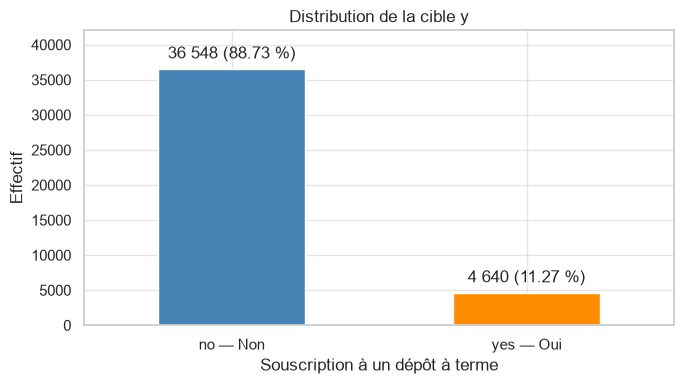

In [11]:
# 3.4 Variable cible : équilibre des classes / distribution

effectifs_cible = df["y"].value_counts().reindex(["no", "yes"], fill_value=0)
pourcentages_cible = df["y"].value_counts(normalize=True).reindex(["no", "yes"], fill_value=0) * 100
distribution_cible = pd.DataFrame({
    "Effectif": effectifs_cible,
    "Pourcentage (%)": pourcentages_cible.round(2),
})
print(distribution_cible.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
effectifs_cible.plot.bar(ax=ax, color=["steelblue", "darkorange"], rot=0)
ax.set_title("Distribution de la cible y")
ax.set_xlabel("Souscription à un dépôt à terme")
ax.set_ylabel("Effectif")
ax.set_xticklabels(["no — Non", "yes — Oui"])
ax.bar_label(
    ax.containers[0],
    labels=[f"{n:,} ({p:.2f} %)".replace(",", " ")
            for n, p in zip(effectifs_cible, pourcentages_cible)],
    padding=5,
)
ax.set_ylim(0, effectifs_cible.max() * 1.15)
fig.tight_layout()
plt.show()

# La cible comprend 36 548 non-souscriptions (88,73 %) et 4 640 souscriptions (11,27 %).
# Les classes sont déséquilibrées : la classe « yes » est nettement minoritaire, comme déjà relevé lors des premières observations.


In [ ]:
# 3.5 Corrélations & relations entre variables
# Matrice de corrélation, pairplot, croisements clés vs cible

In [ ]:
# Copie dédiée aux graphiques : 999 est écarté des délais numériques de pdays.
# Les données df restent inchangées ; chaque corrélation utilise les valeurs disponibles.
donnees_relations = df.copy()
donnees_relations["pdays"] = donnees_relations["pdays"].replace(999, np.nan)
donnees_relations["y_oui"] = donnees_relations["y"].map({"no": 0, "yes": 1})
colonnes_num = df.select_dtypes(include="number").columns.tolist()
colonnes_cat = df.drop(columns="y").select_dtypes(exclude="number").columns.tolist()

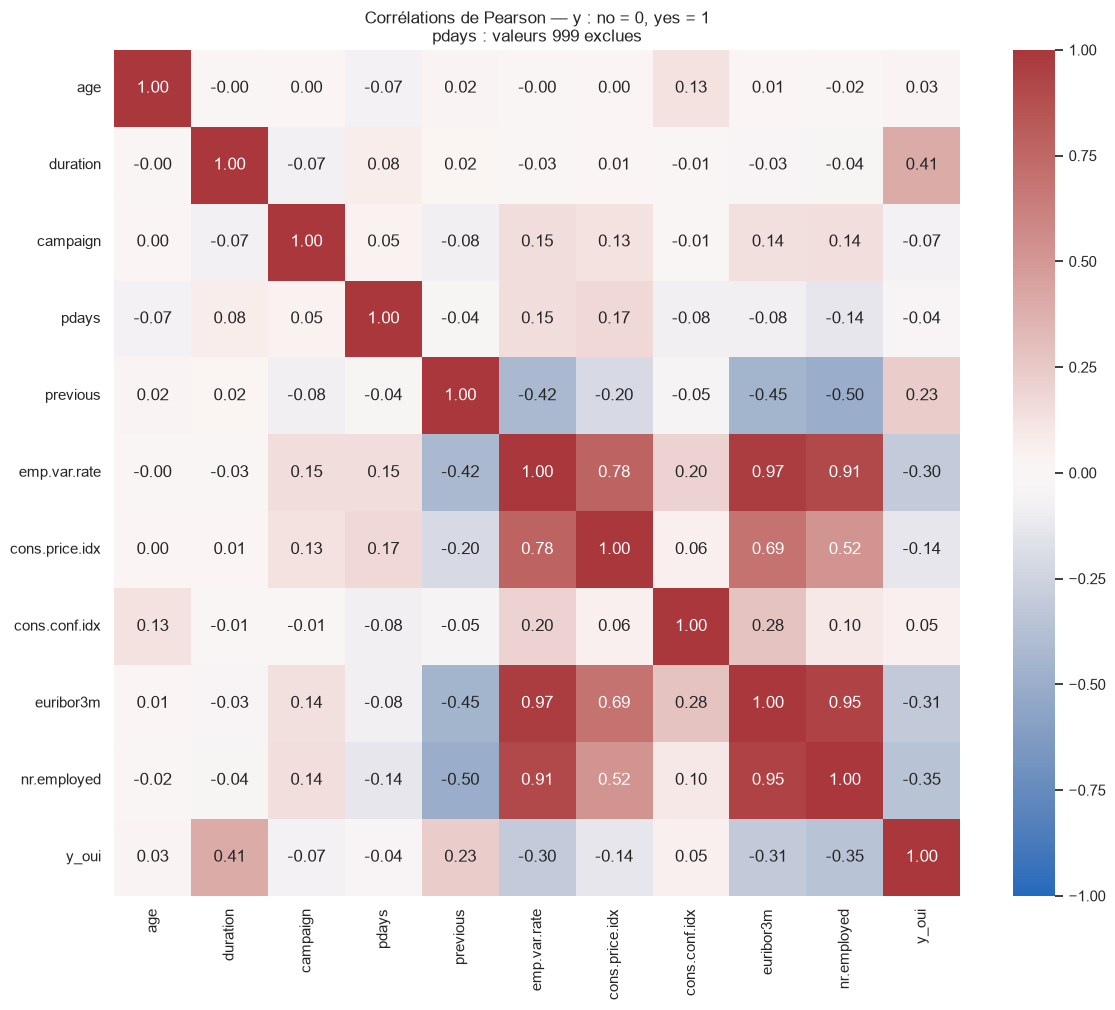

In [12]:
## MATRICE DE CORRÉLATION
correlations = donnees_relations[colonnes_num + ["y_oui"]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Corrélations de Pearson — y : no = 0, yes = 1\npdays : valeurs 999 exclues")
fig.tight_layout()
plt.show()

# Les fortes corrélations entre indicateurs économiques sont plausibles, car ils décrivent un contexte commun au fil des mêmes périodes.
# emp.var.rate, euribor3m et nr.employed sont très corrélés (0,91 à 0,97) : leur information est en partie redondante et leur maintien conjoint sera à évaluer.
# cons.conf.idx est peu corrélé aux autres indicateurs économiques (0,06 à 0,28) et décrit une dimension différente du contexte.
# duration est la variable numérique la plus corrélée à la souscription (+0,41), mais elle reste indisponible avant l’appel et constitue une fuite d’information.
# nr.employed (−0,35), euribor3m (−0,31) et emp.var.rate (−0,30) sont associés à la cible ; la pertinence du modèle sur une autre période sera à vérifier.
# previous est positivement associé à la souscription (+0,23), sans démontrer que multiplier les contacts provoque une souscription.
# age est peu corrélé linéairement à la cible (+0,03), ce qui laisse possible une relation différente selon les tranches d’âge.
# La corrélation de pdays avec la cible (−0,04) concerne uniquement les délais différents de 999 ; le statut 999 est étudié séparément.


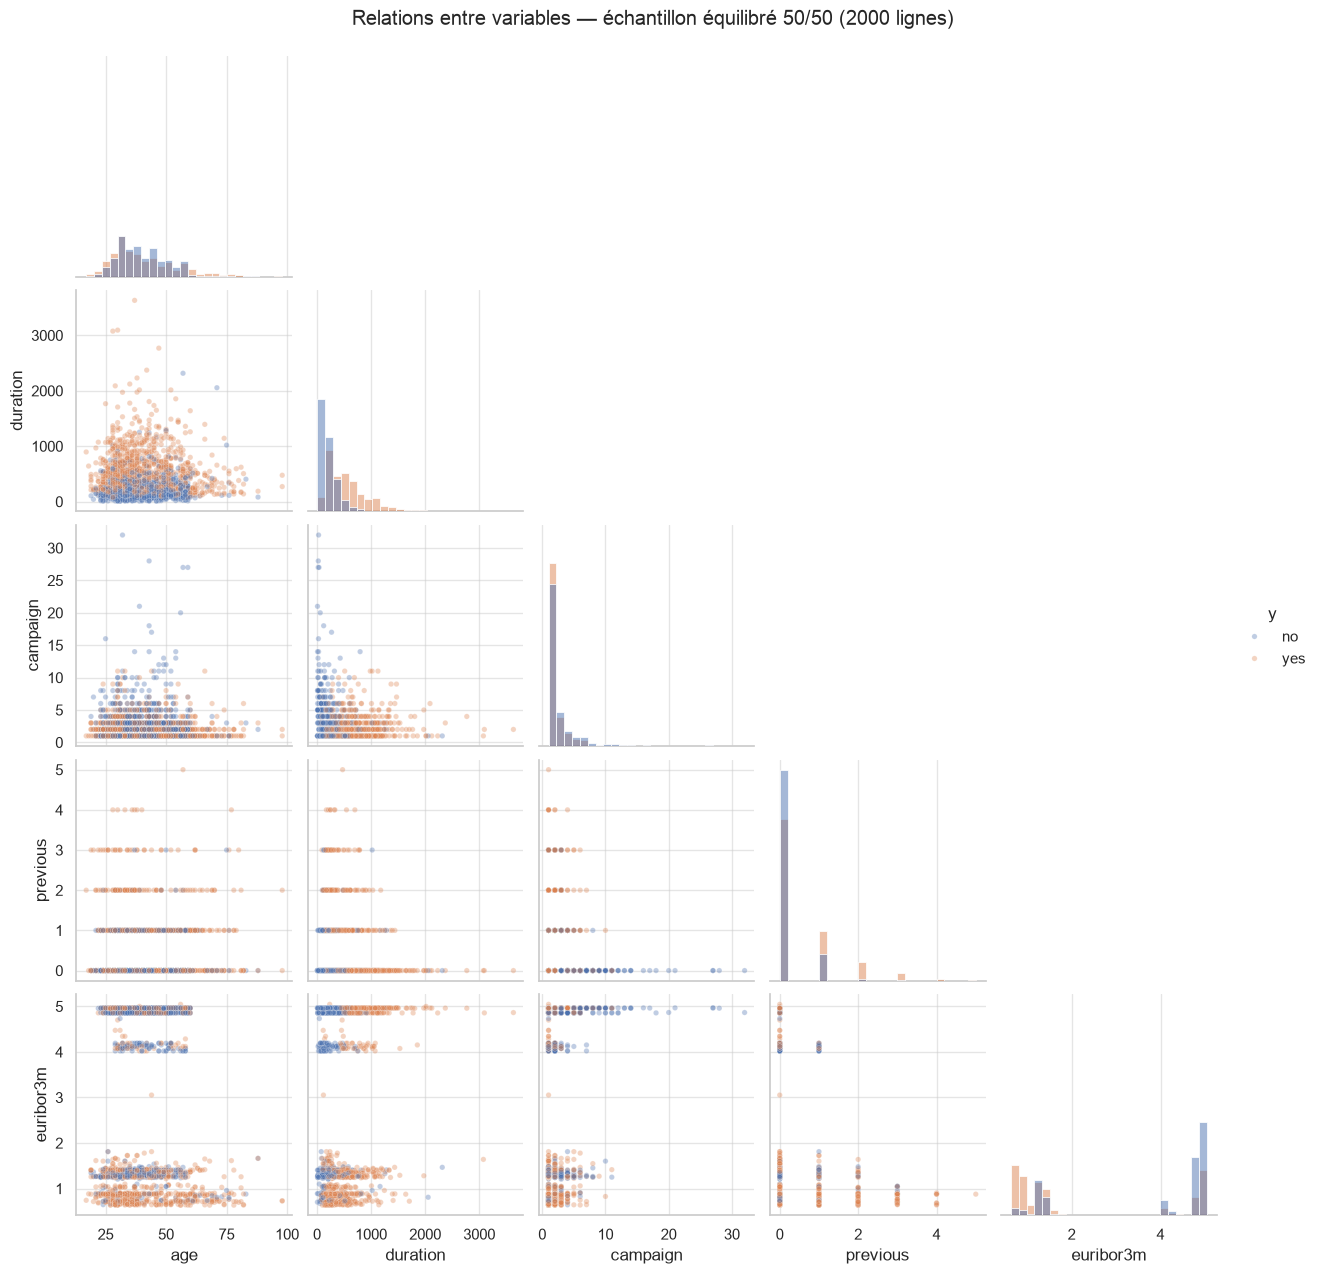

In [26]:
## PAIRPLOT
# Échantillon reproductible équilibré pour le graphique : 1 000 lignes par classe.
variables_pairplot = ["age", "duration", "campaign", "previous", "euribor3m"]
echantillon_relations = pd.concat([
    donnees_relations.loc[donnees_relations["y"].eq(classe)].sample(
        n=1000, random_state=RANDOM_STATE
    )
    for classe in ["no", "yes"]
]).sample(frac=1, random_state=RANDOM_STATE)
g = sns.pairplot(echantillon_relations, vars=variables_pairplot, hue="y",
                 hue_order=["no", "yes"], corner=True, diag_kind="hist",
                 plot_kws={"alpha": 0.35, "s": 15}, diag_kws={"bins": 25})
g.fig.suptitle(f"Relations entre variables — échantillon équilibré 50/50 ({len(echantillon_relations)} lignes)", y=1.02)
plt.show()

# duration distingue visuellement les classes, mais reste exclue du ciblage avant appel pour fuite d’information.
# previous et euribor3m semblent liés : leur apport prédictif propre reste à vérifier lors de la modélisation.
# Les classes se chevauchent largement ; ces croisements ne font apparaître aucune règle simple de séparation.


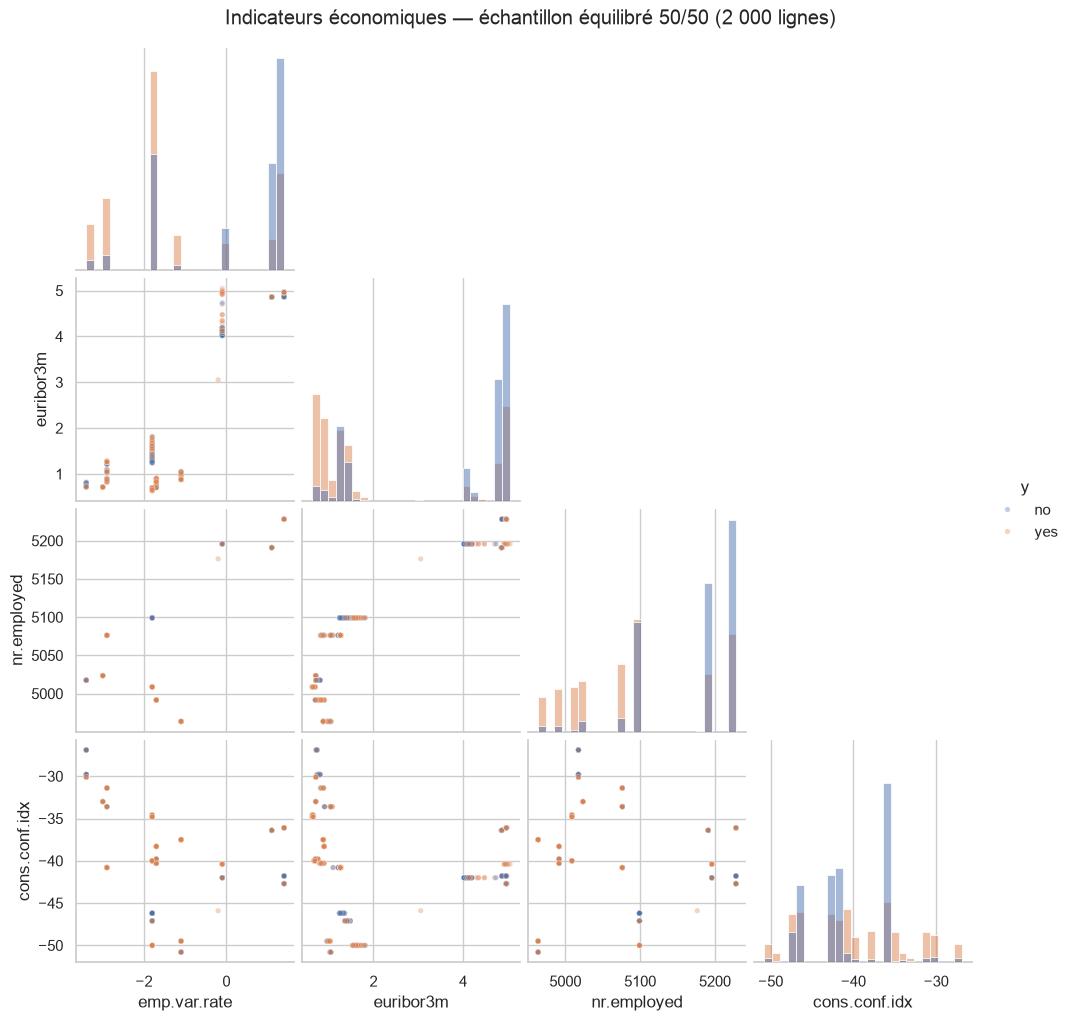

In [ ]:
## RELATIONS ENTRE INDICATEURS ÉCONOMIQUES
# Même échantillon équilibré 50/50 pour explorer la redondance et cons.conf.idx.
variables_economiques = ["emp.var.rate", "euribor3m", "nr.employed", "cons.conf.idx"]
g = sns.pairplot(echantillon_relations, vars=variables_economiques, hue="y",
                 hue_order=["no", "yes"], corner=True, diag_kind="hist",
                 plot_kws={"alpha": 0.35, "s": 15}, diag_kws={"bins": 25})
g.fig.suptitle("Indicateurs économiques — échantillon équilibré 50/50 (2 000 lignes)", y=1.02)
plt.show()

# emp.var.rate, euribor3m et nr.employed portent une information en partie redondante : comparer leur apport conjoint à celui d’un sous-ensemble.
# cons.conf.idx présente des relations moins linéaires avec les autres indicateurs ; son utilité prédictive reste à évaluer.
/Users/franckcwalter/Pictures/snap/Capture d’écran 2026-09-24 à 23.13.56.png

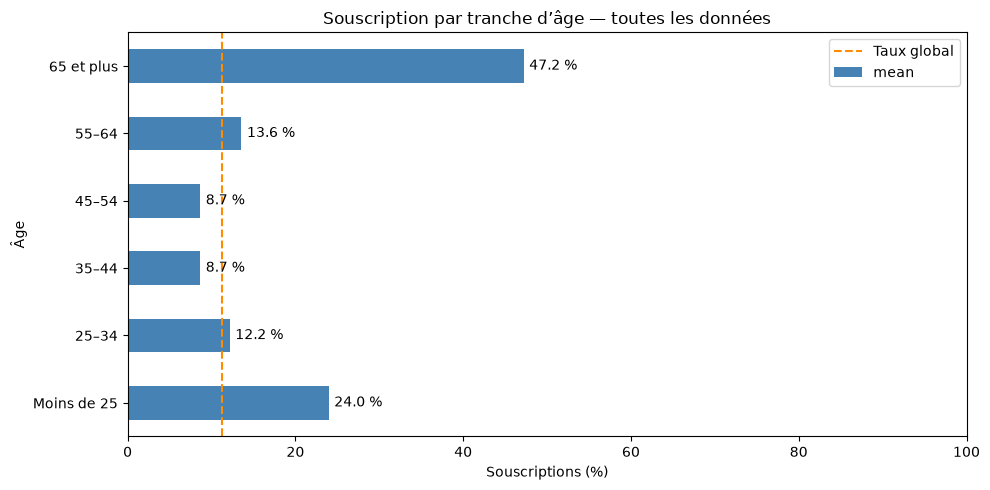

In [ ]:
## TAUX DE SOUSCRIPTION PAR TRANCHE D’ÂGE
# Taux calculés sur toutes les données.
tranches_age = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, np.inf],
                      labels=["Moins de 25", "25–34", "35–44", "45–54", "55–64", "65 et plus"], right=False)
stats_age = donnees_relations.groupby(tranches_age, observed=True)["y_oui"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(10, 5))
(stats_age["mean"] * 100).plot.barh(ax=ax, color="steelblue")
ax.bar_label(ax.containers[0], labels=[f"{t * 100:.1f} %" for t in stats_age["mean"]], padding=4)
ax.axvline(donnees_relations["y_oui"].mean() * 100, color="darkorange", linestyle="--", label="Taux global")
ax.set(title="Souscription par tranche d’âge — toutes les données", xlabel="Souscriptions (%)", ylabel="Âge", xlim=(0, 100))
ax.legend()
fig.tight_layout()
plt.show()

# Taux et effectifs : moins de 25 ans 24,0 %, 25–34 ans 12,2 %, 35–44 ans 8,7 %, 45–54 ans 8,7 %, 55–64 ans 13,6 %, 65 ans et plus 47,2 %.


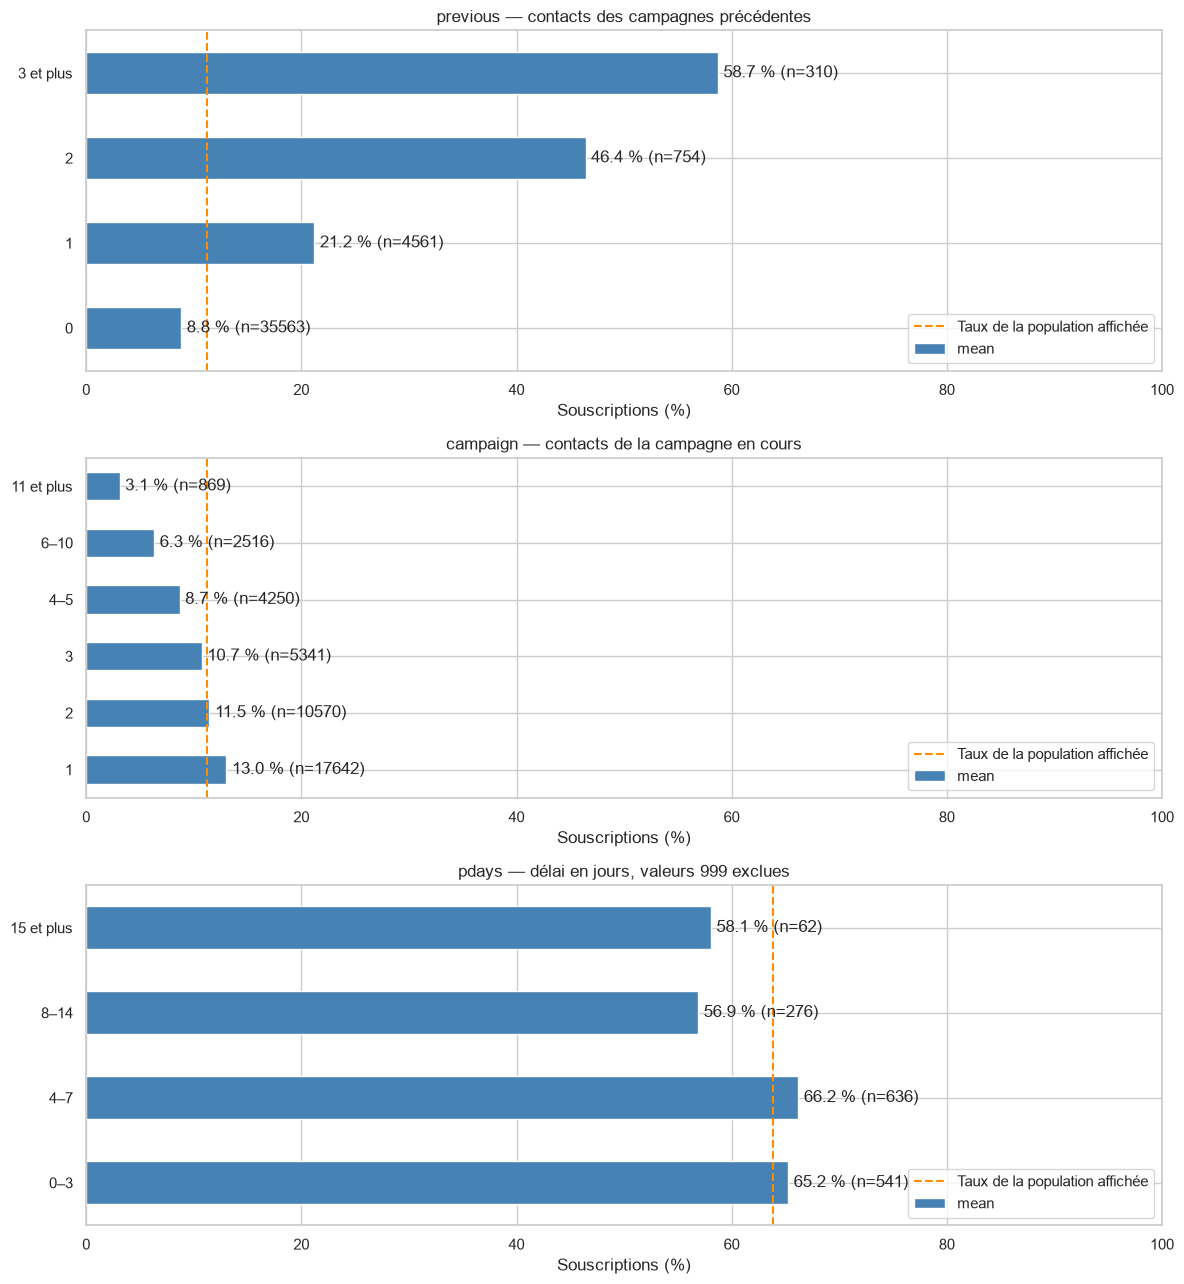

In [ ]:
## TAUX DE SOUSCRIPTION SELON LES CONTACTS ET LES DÉLAIS
# Toutes les données ; les délais réels de pdays sont étudiés hors code 999.
groupes_contacts = {
    "previous — contacts des campagnes précédentes": pd.cut(
        df["previous"], bins=[-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3 et plus"]),
    "campaign — contacts de la campagne en cours": pd.cut(
        df["campaign"], bins=[0, 1, 2, 3, 5, 10, np.inf], labels=["1", "2", "3", "4–5", "6–10", "11 et plus"]),
    "pdays — délai en jours, valeurs 999 exclues": pd.cut(
        donnees_relations["pdays"], bins=[-1, 3, 7, 14, np.inf], labels=["0–3", "4–7", "8–14", "15 et plus"]),
}
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
for ax, (titre, groupes) in zip(axes, groupes_contacts.items()):
    stats_contacts = donnees_relations.groupby(groupes, observed=True)["y_oui"].agg(["mean", "size"])
    (stats_contacts["mean"] * 100).plot.barh(ax=ax, color="steelblue")
    ax.bar_label(ax.containers[0], labels=[f"{t * 100:.1f} %" for t in stats_contacts["mean"]], padding=4)
    population = donnees_relations.loc[groupes.notna(), "y_oui"]
    ax.axvline(population.mean() * 100, color="darkorange", linestyle="--", label="Taux de la population affichée")
    ax.set(title=titre, xlabel="Souscriptions (%)", ylabel="", xlim=(0, 100))
    ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# previous : taux de souscription croissant avec les contacts antérieurs : 8,8 % (35 563), 21,2 % (4 561), 46,4 % (754), 58,7 % (310, 3+ contacts).
# campaign : taux décroissant avec les contacts en cours : de 13,0 % (17 642, 1 contact) à 3,1 % (869, 11+ contacts).
# pdays (hors 999) : taux de 65,2 % (541), 66,2 % (636), 56,9 % (276), 58,1 % (62, 15+ jours) ; dernier groupe peu nombreux.


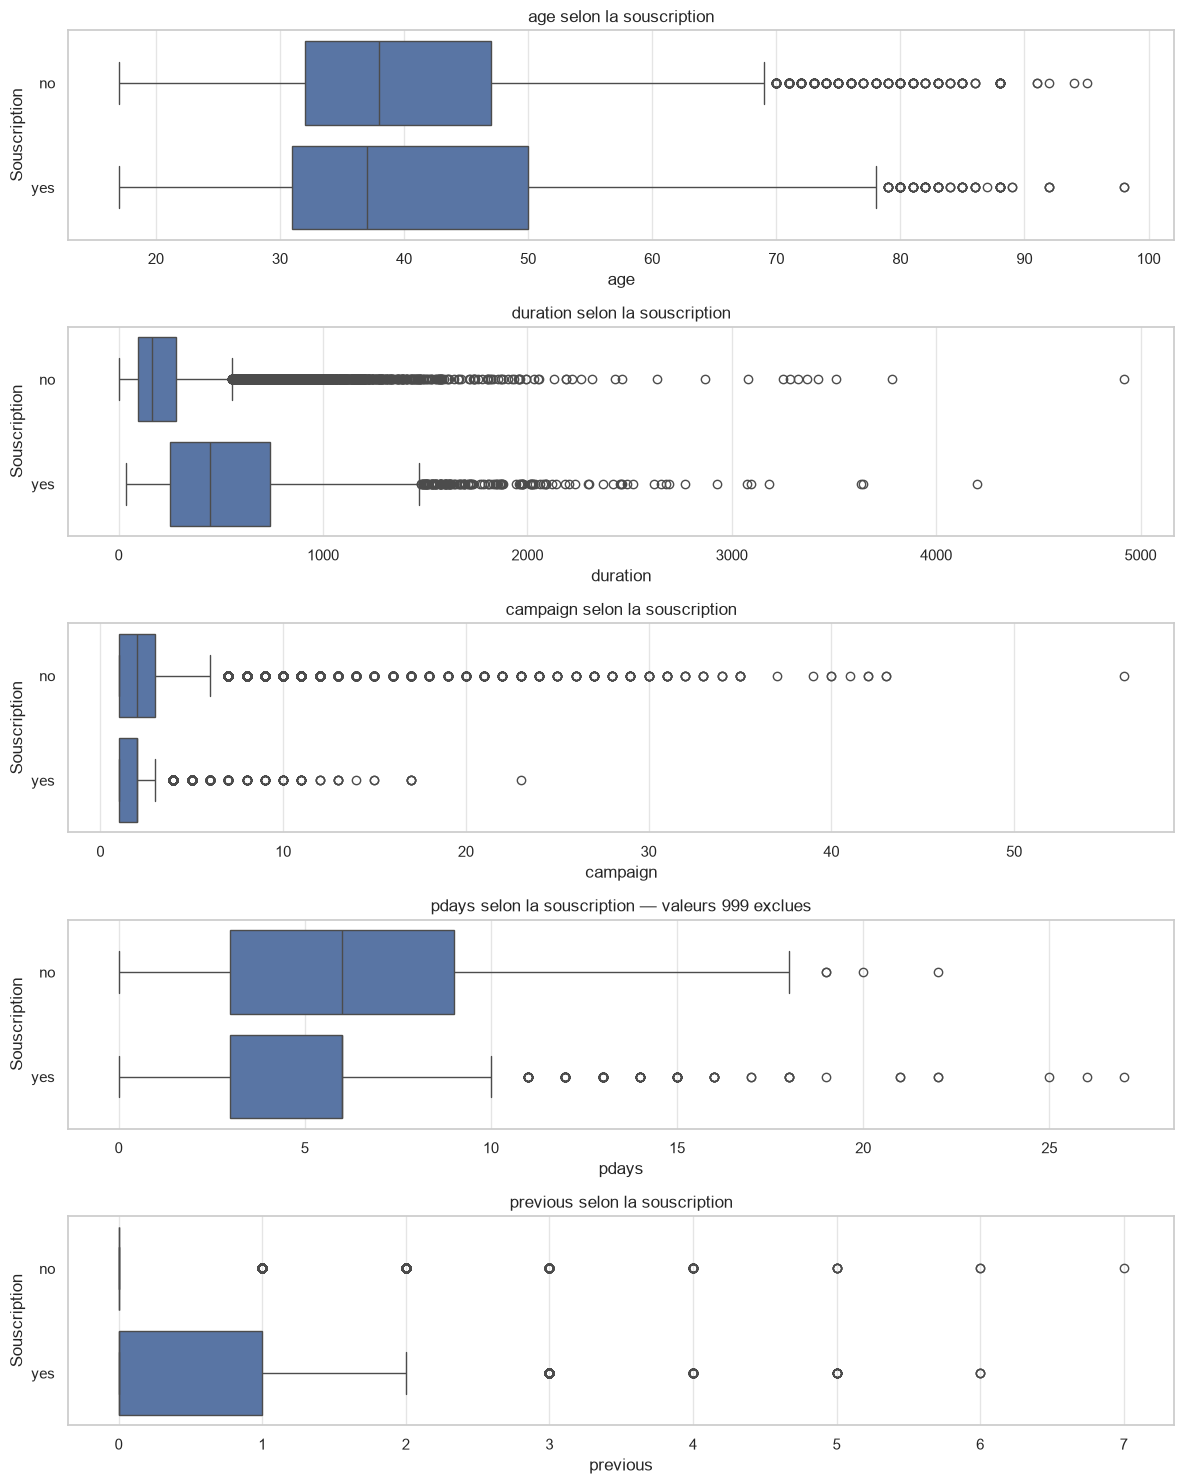

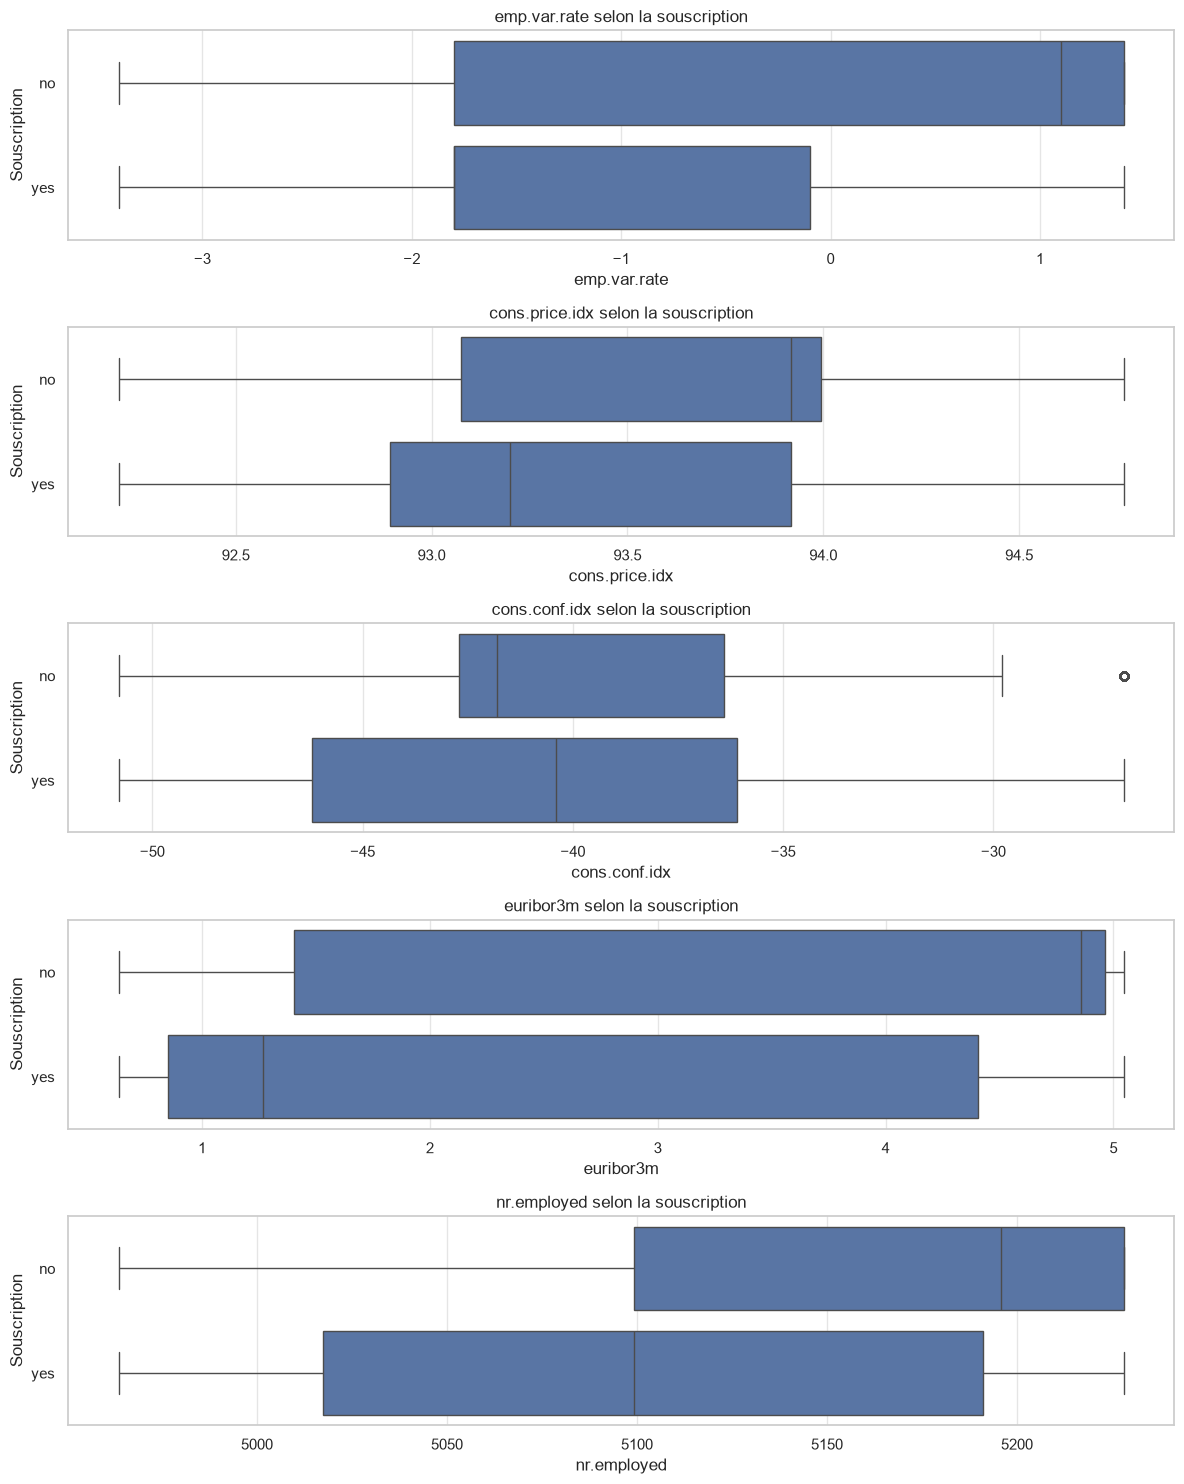

In [14]:
## VARIABLES NUMÉRIQUES SELON LA CIBLE
# Distribution des variables numériques selon la souscription.
for debut in range(0, len(colonnes_num), 5):
    groupe = colonnes_num[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 1, figsize=(12, 3 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        ax = axes[ligne, 0]
        sns.boxplot(data=donnees_relations, x=variable, y="y", order=["no", "yes"], ax=ax)
        titre = f"{variable} selon la souscription"
        if variable == "pdays":
            titre += " — valeurs 999 exclues"
        ax.set_title(titre)
        ax.set_ylabel("Souscription")
    fig.tight_layout()
    plt.show()

# age : les médianes sont proches (38 et 37 ans), mais les souscripteurs sont plus dispersés et comptent davantage de clients de plus de 60 ans, cohérent avec le taux élevé des 65 ans et plus.
# duration : les appels suivis d’une souscription sont nettement plus longs (médiane 449 s contre 164 s), ce qui confirme la fuite d’information déjà relevée.
# campaign : les souscripteurs ont été contactés moins souvent pendant la campagne ; au-delà de quelques appels, les souscriptions deviennent rares.
# pdays : hors code 999, les souscripteurs ont été recontactés dans un délai plus court et plus resserré, avec une médiane identique de 6 jours.
# previous : 32 % des souscripteurs ont eu au moins un contact antérieur, contre 11 % des non-souscripteurs.
# emp.var.rate, cons.price.idx, euribor3m et nr.employed : les souscriptions se concentrent sur les périodes de taux bas et d’emploi en recul, comme sur la matrice de corrélation.
# cons.conf.idx : les deux distributions se chevauchent largement, avec des médianes proches (−41,8 et −40,4) ; son apport propre reste à vérifier.


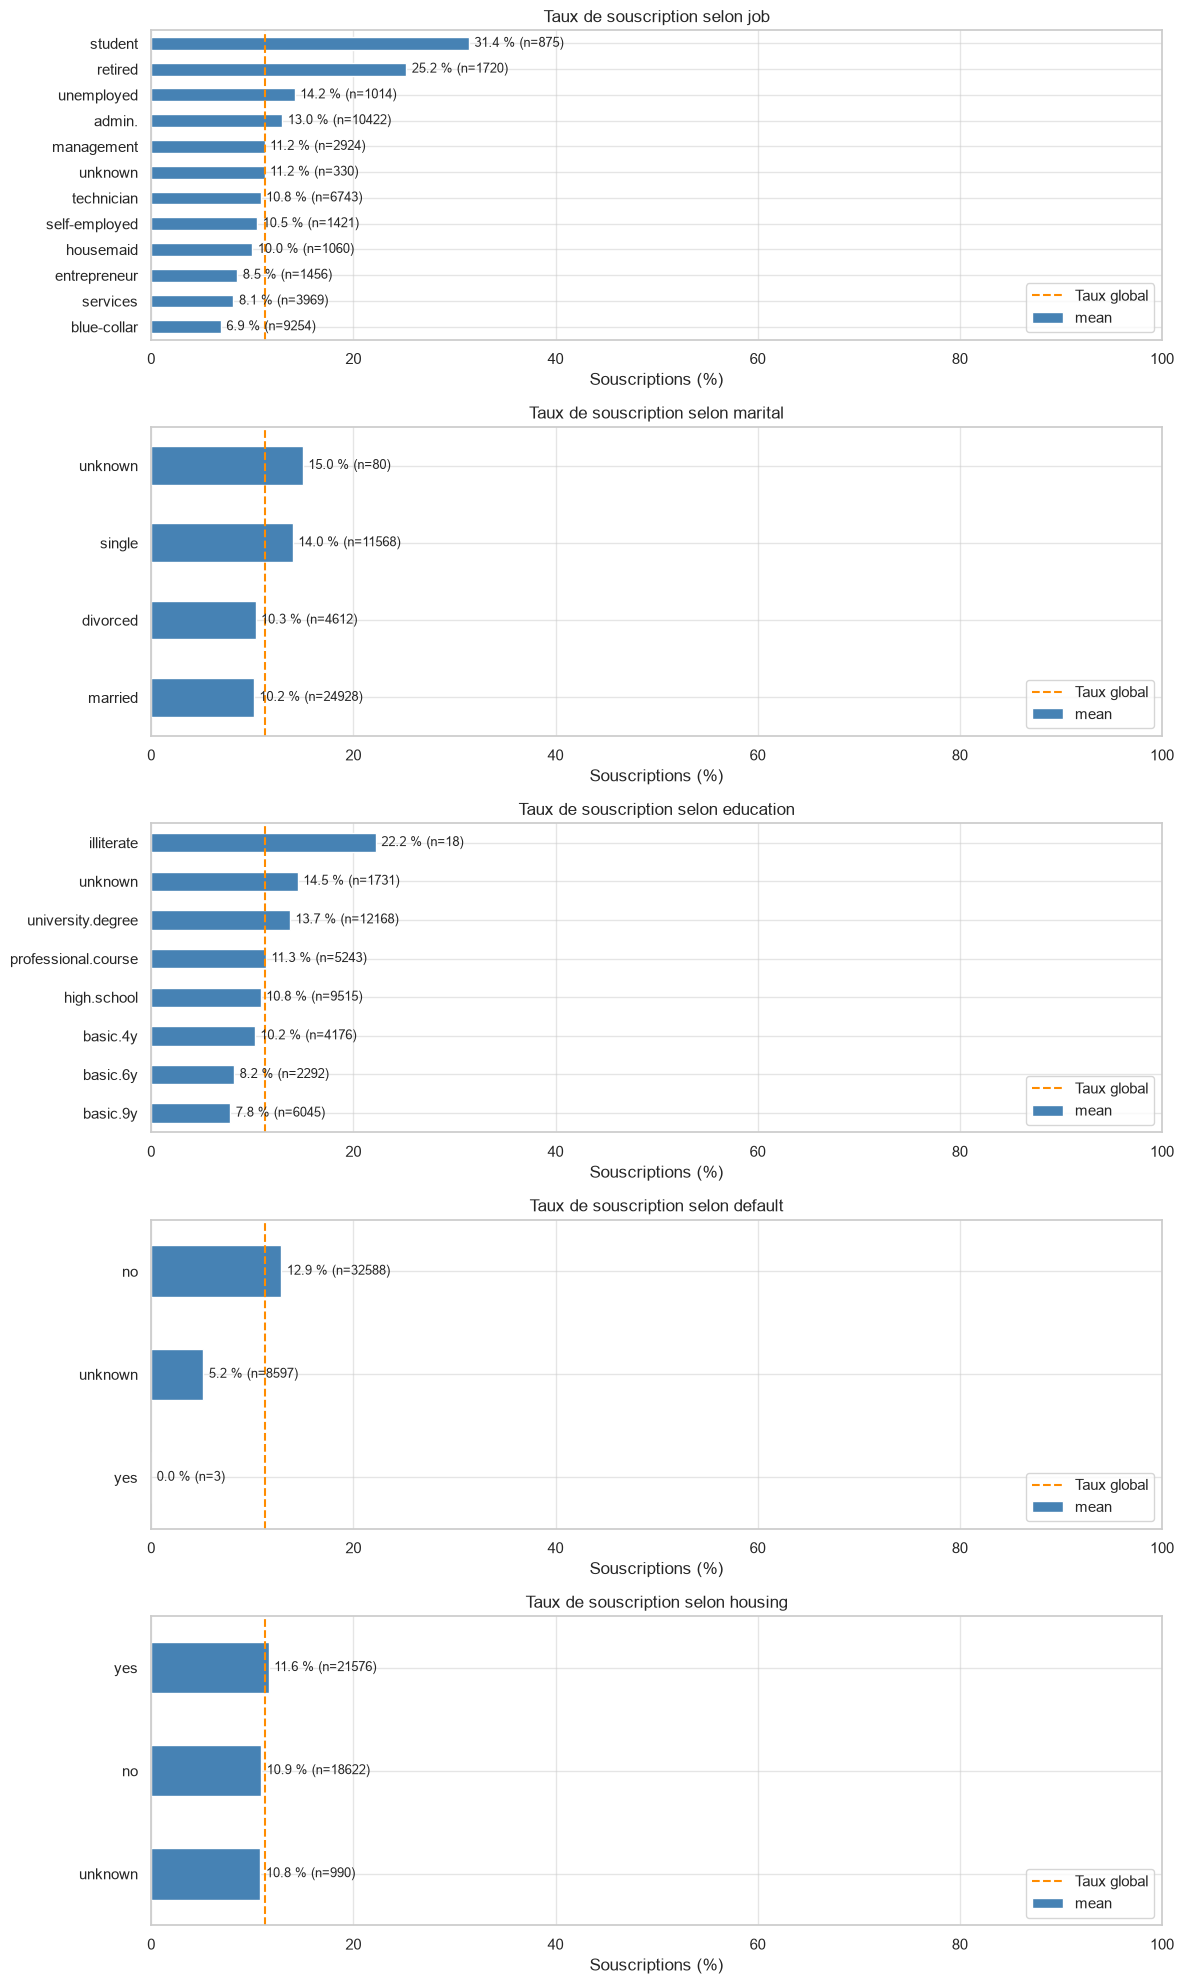

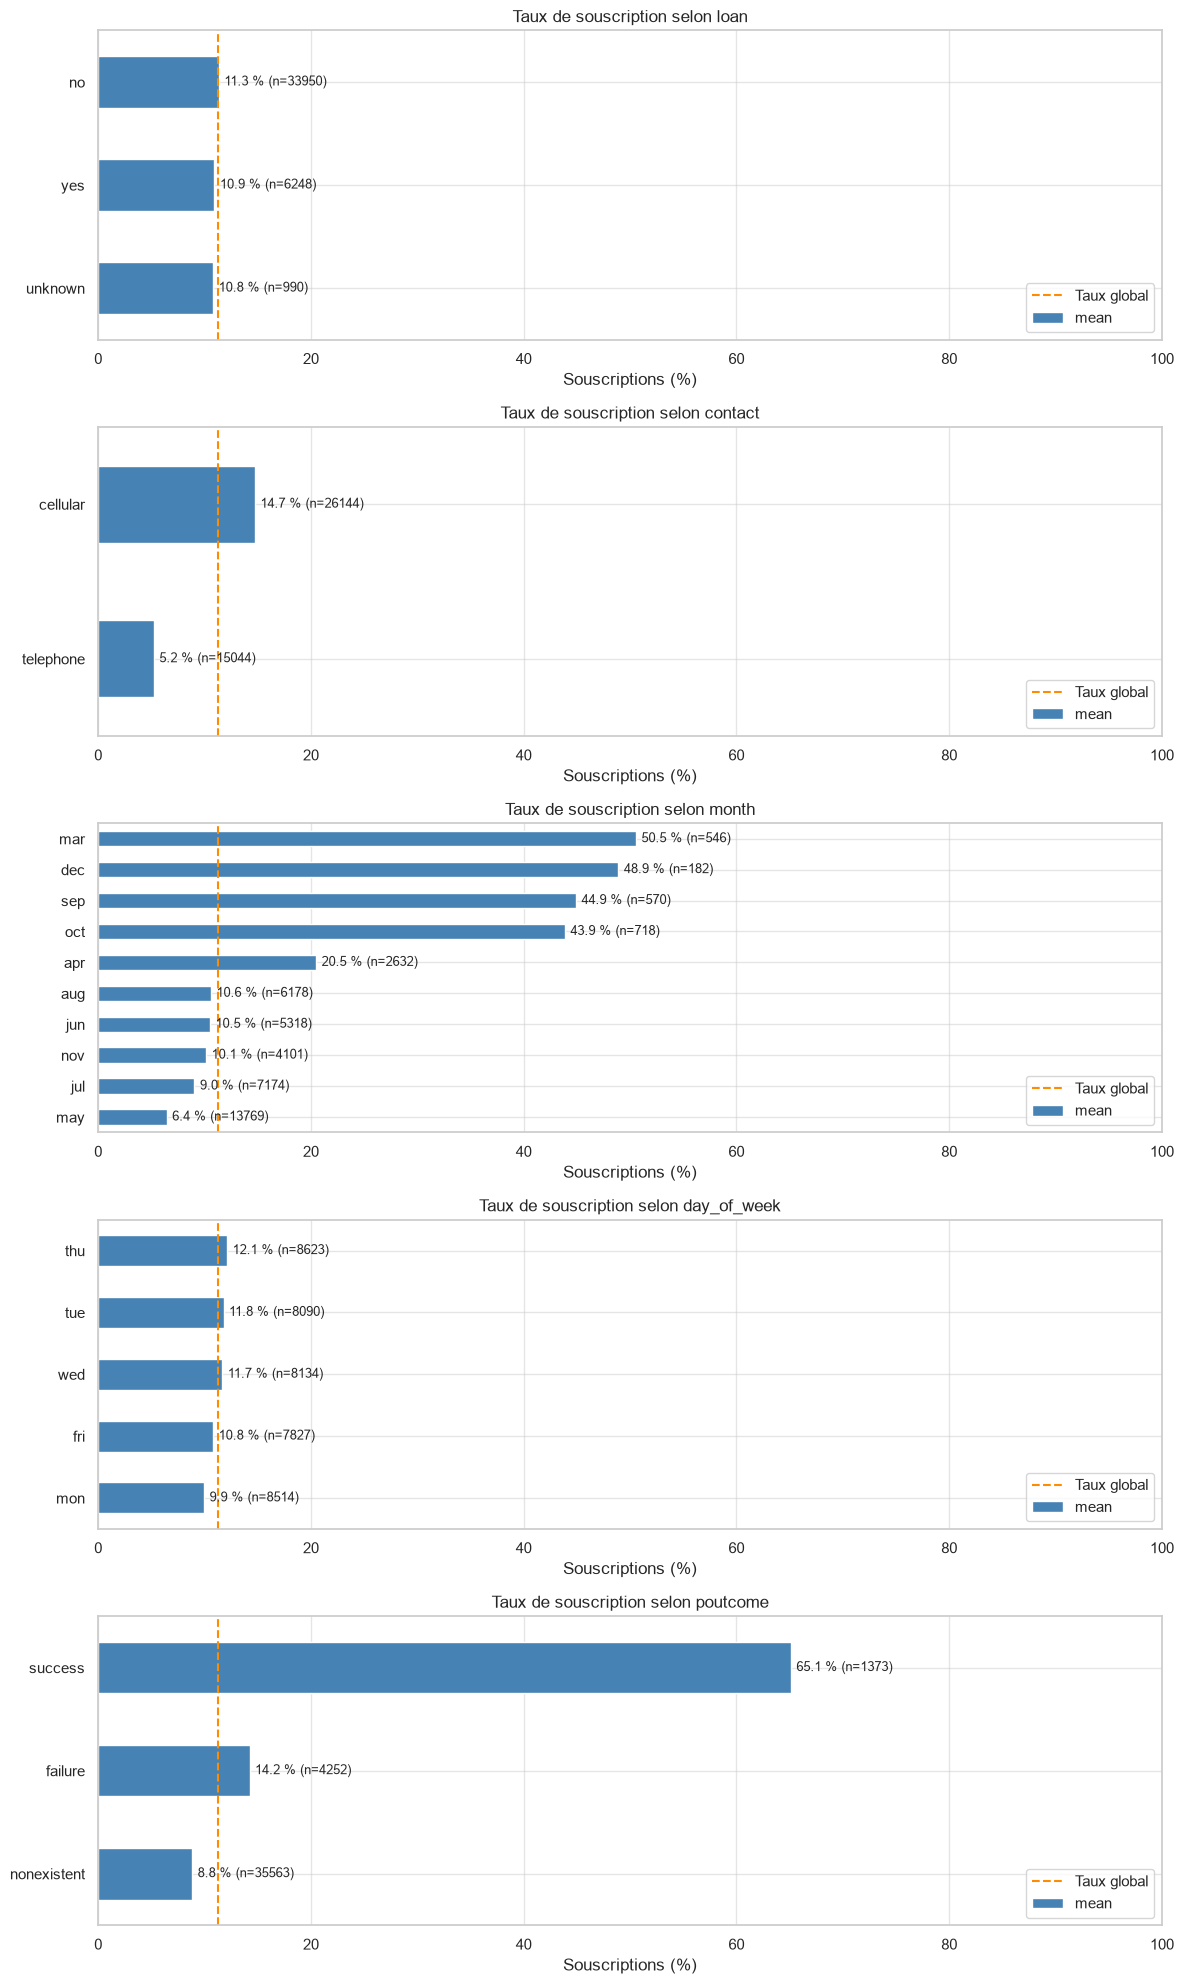

In [15]:
## TAUX DE SOUSCRIPTION PAR MODALITÉ
# Taux de souscription par modalité.
for debut in range(0, len(colonnes_cat), 5):
    groupe = colonnes_cat[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 1, figsize=(12, 4 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        tableau = donnees_relations.groupby(variable, dropna=False)["y_oui"].agg(["mean", "size"])
        tableau = tableau.sort_values("mean")
        ax = axes[ligne, 0]
        (tableau["mean"] * 100).plot.barh(ax=ax, color="steelblue")
        ax.axvline(donnees_relations["y_oui"].mean() * 100, color="darkorange",
                   linestyle="--", label="Taux global")
        ax.bar_label(ax.containers[0],
                     labels=[f"{taux * 100:.1f} %" for taux in tableau["mean"]],
                     padding=4, fontsize=9)
        ax.set_title(f"Taux de souscription selon {variable}")
        ax.set_xlabel("Souscriptions (%)")
        ax.set_ylabel("")
        ax.set_xlim(0, 100)
        ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()

# job : les étudiants (31,4 %) et les retraités (25,2 %) souscrivent le plus, cohérent avec les taux élevés des moins de 25 ans et des 65 ans et plus ; les ouvriers (blue-collar) souscrivent le moins (6,9 %).
# marital : les célibataires souscrivent un peu plus (14,0 %) que les mariés et les divorcés (environ 10 %) ; l’écart recoupe en partie celui de l’âge.
# education : les écarts restent modérés, de 7,8 % (basic.9y) à 13,7 % (university.degree) ; le taux de illiterate (22,2 %) repose sur 18 clients seulement.
# default : les clients au statut unknown souscrivent nettement moins (5,2 %) que les clients sans défaut (12,9 %) ; unknown porte une information et sera gardé comme modalité à part.
# default : la modalité yes ne compte que 3 clients, trop peu pour être exploitée seule.
# housing et loan : les taux restent proches du taux global (10,8 % à 11,6 %) ; ces deux variables semblent peu discriminantes.
# contact : les clients joints sur mobile souscrivent près de trois fois plus (14,7 %) que sur téléphone fixe (5,2 %).
# month : mai concentre le plus d’appels pour le taux le plus bas (6,4 %), tandis que mars, septembre, octobre et décembre dépassent 43 % sur de faibles effectifs ; le mois reflète la période de campagne.
# day_of_week : les taux varient peu selon le jour (9,9 % à 12,1 %) ; cette variable semble peu discriminante.
# poutcome : un succès lors d’une campagne précédente donne le taux le plus élevé (65,1 %), contre 14,2 % après un échec et 8,8 % sans campagne précédente.


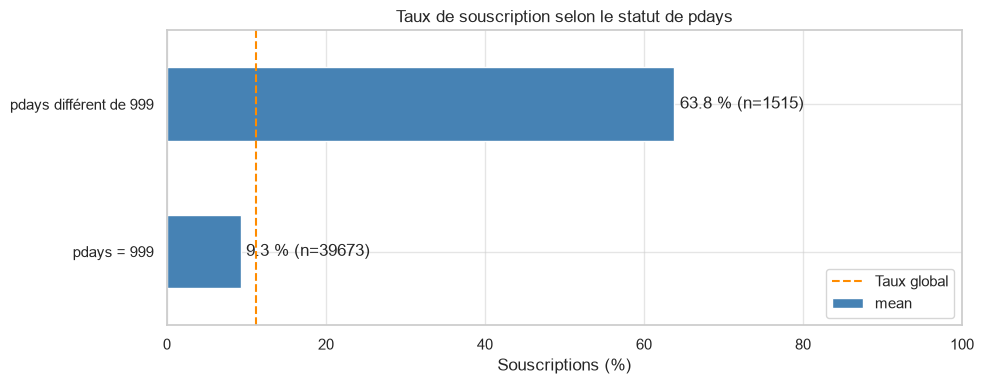

In [16]:
## CROISEMENT DE PDAYS AVEC LA CIBLE
# Croisement spécifique du code 999 de pdays avec la cible.
statut_pdays = df["pdays"].eq(999).map({True: "pdays = 999", False: "pdays différent de 999"})
taux_pdays = donnees_relations.groupby(statut_pdays)["y_oui"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(10, 4))
(taux_pdays["mean"] * 100).plot.barh(ax=ax, color="steelblue")
ax.bar_label(ax.containers[0],
             labels=[f"{taux * 100:.1f} %" for taux in taux_pdays["mean"]], padding=4)
ax.axvline(donnees_relations["y_oui"].mean() * 100, color="darkorange",
           linestyle="--", label="Taux global")
ax.set_title("Taux de souscription selon le statut de pdays")
ax.set_xlabel("Souscriptions (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Les clients recontactés après une campagne précédente (pdays différent de 999) souscrivent à 63,8 %, contre 9,3 % pour les clients jamais recontactés.
# Le code 999 porte donc une information forte sur la cible : le remplacer par un délai fictif la ferait perdre, un indicateur « déjà recontacté » est à prévoir au prétraitement.


### 3.6 Analyse des biais & variables sensibles

*[Quelles variables peuvent porter un biais (genre, âge, origine, profession des parents…) ? La cible est-elle inégalement répartie selon ces variables ? Disparate impact ?]*

### 3.7 📝 Synthèse EDA

*[Top 5 enseignements de l'EDA. Hypothèses de travail pour la modélisation. Risques de biais identifiés. **Révision éventuelle des cibles 1.4** à la lumière de la donnée.]*

---
## 4. Préparation des données

**Compétences** : C3 (préparer les données pour renforcer intégrité et pertinence)

🎯 Construire un **pipeline reproductible** de préprocessing (pas de transformations one-shot dispersées).

💡 `sklearn.compose.ColumnTransformer` + `sklearn.pipeline.Pipeline` = base obligatoire.  
⚠️ Le **train/test split DOIT précéder** tout calcul d'imputation/normalisation, sinon fuite de données.

In [17]:
# 4.1 Train/test split (stratifié si classification déséquilibrée)
# from sklearn.model_selection import train_test_split
# X = df.drop(columns=["target"])
# y = df["target"]
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
# )

In [18]:
# 4.2 Recette de préprocessing — une FONCTION, pas un objet figé
# Les scénarios de 4.3 changent le PERIMETRE des données utilisées (parfois un
# type de données entier). Les traitements, eux, ne changent pas.
# On écrit donc la recette une fois, on l'instancie par scénario en 5.2.
#
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
#
# num_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler()),
# ])
# cat_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore")),
# ])
#
# def make_preprocessor(num_features=None, cat_features=None):
#     """Instancie la MEME recette sur le perimetre demande.
#
#     Chaque bloc est OPTIONNEL : c'est ce qui permet a un scenario de 4.3 de
#     retirer un type de donnees entier sans changer les traitements.
#     Meme recette partout = comparabilite.
#     """
#     blocks = []
#     if num_features:
#         blocks.append(("num", num_pipe, num_features))
#     if cat_features:
#         blocks.append(("cat", cat_pipe, cat_features))
#     # TODO si ton cas comporte un autre type de donnees (texte libre, image,
#     #      serie temporelle) : ajoute ici un bloc sur le meme modele, avec le
#     #      transformer adapte et son propre parametre optionnel. A toi de
#     #      trouver la forme d'entree qu'attend ce transformer.
#     assert blocks, "Aucune colonne : verifie le perimetre du scenario"
#     return ColumnTransformer(blocks)
#
# Aucun .fit() ici : le fit se fait dans le Pipeline complet (5.2), sur le train
# de chaque fold de CV. Un fit premature ici = fuite de donnees.


### 4.3 Scénarios de jeux de données

*[Pour la certif, anticipe : 2 à 4 scénarios = avec/sans variables sensibles, avec/sans certaines variables corrélées à la cible. Liste-les ici, tu les compareras en section 6.]*

| Scénario | Variables conservées | Justification |
|---|---|---|
| S1 | Toutes | Baseline |
| S2 | Sans variables sensibles | Atténuation biais |
| S3 | … | … |

> ⚠️ **Un scénario change le périmètre, jamais la recette.**
> Chaque scénario instancie `make_preprocessor(...)` (4.2) avec ce qui lui
> reste : mêmes imputer / scaler / encodage partout, seul le périmètre change.
> C'est ce que veut dire « même prétraitement » dans la règle d'or de
> comparabilité — pas « le même objet `ColumnTransformer` ».
>
> Un scénario peut retirer **un type de données entier** et pas seulement
> quelques colonnes : d'où les blocs optionnels de `make_preprocessor`. Le
> nombre de branches du `ColumnTransformer` varie, les transformations non.
>
> Et on ne fait varier **qu'un facteur à la fois** : même modèle d'un scénario
> à l'autre, même scénario d'un modèle à l'autre. Sinon le tableau de la
> section 6 ne permet aucune conclusion.
>
> 💡 Si un scénario repose sur du *feature engineering* (variable dérivée,
> regroupement, agrégat), la colonne dérivée se calcule **avant**
> `make_preprocessor` et y entre comme une colonne ordinaire.

### 4.4 📝 Synthèse préparation

*[Choix de pipeline, scénarios construits, traçabilité.]*

### 4.5 Assertions de qualité (indispensable !)

🎯 Avant de passer à la modélisation, **vérifie via des `assert`** que la donnée préparée est saine. Une assertion qui échoue arrête le notebook : c'est le but.

💡 Ces assertions sont la **première ligne de tests automatisés** que tu généraliseras en M5 (pytest).  
⚠️ Si l'une d'elles casse, ne la commente pas. Cherche pourquoi avant de modéliser.

In [19]:
# Exemples d'assertions de qualité — adapte-les à ton dataset
# assert df.shape[0] > 0, "Dataset vide après préparation"
# assert df["target"].isna().sum() == 0, "Manquants résiduels dans la cible"
# assert df.duplicated().sum() == 0, "Doublons résiduels"
# assert set(df["target"].unique()).issubset({0, 1}), "Cible binaire attendue"
# assert (X_train.shape[0] + X_test.shape[0]) == df.shape[0], "Split incomplet"

---
## 5. Modélisation & entraînement

**Compétences** : C4 (choisir un modèle adapté), C5 (entraîner le modèle)

🎯 **Comparer plusieurs modèles** avec validation croisée, choisir, justifier.

💡 Démarche scientifique : on pose une hypothèse, on teste, on compare. Pas un seul modèle « parce que je connais ».  
⚠️ Le scoring de validation croisée se fait **sur le train uniquement**. Le test set ne sert qu'à la fin.

### 5.0 Familles de modèles candidates

🎯 **Avant** de retenir des modèles concrets en §5.1, force-toi à considérer explicitement les **grandes familles** de solutions IA. Documente celles que tu **écartes** et **pourquoi**. C'est un attendu structurant : on ne te jugera pas sur le fait d'avoir essayé un LLM, on te jugera sur ta capacité à argumenter pourquoi tu n'en as pas eu besoin (ou pourquoi si).

> 🚦 **Mobilisation progressive** : cette section s'ouvre dès **M1** mais s'enrichit au fil du parcours.
> - **M1-M4** : remplis sérieusement les lignes **ML classique** et **Deep Learning**. Les 3 autres familles peuvent être écartées en 1 ligne (« hors scope module »).
> - **M6** : enrichis si tu as croisé un cas où le DL devenait pertinent.
> - **M7-M8** : à ce stade, **toutes les lignes** doivent recevoir un arbitrage motivé (SLM, LLM+RAG, agentique inclus). C'est précisément ce que valident M7-B2 (comparaison ML / RAG / agents) et M8-B2 (arbitrage SLM / LLM).

💡 5 familles à interroger systématiquement, même si 4 sont écartées en 30 secondes.  
⚠️ « J'ai pris du RandomForest parce que je connais » n'est pas une justification. « J'ai écarté le LLM parce que coût d'inférence > 100× pour un gain marginal sur tabulaire structuré » en est une.

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (sklearn, XGBoost) | *[ex: oui, données tabulaires structurées, N < 1M]* | faible | élevée | aucune | *[ex: retenue — baseline et candidat sérieux]* |
| Deep Learning (Keras / PyTorch) | *[ex: oui si vision/NLP avec N > 10k]* | élevé (GPU train) | faible | aucune (modèle local) | *[ex: écartée — données tabulaires, ROI nul vs sklearn]* |
| SLM local (Ollama, modèles ≤ 7B) | *[ex: oui si génération de texte courte, on-premise nécessaire]* | moyen | moyenne | aucune | … |
| LLM API + RAG | *[ex: oui si questions ouvertes sur corpus documentaire]* | élevé (€/token) | faible | forte (OpenAI / Anthropic / Mistral) | … |
| Architecture agentique (multi-LLM, tools) | *[ex: oui si orchestration multi-étapes avec actions]* | très élevé | très faible | forte | … |

> ⚠️ Cette grille n'est pas une obligation d'**implémenter** chaque famille. C'est une obligation d'**argumenter le choix de famille**. Pour un problème de classification binaire sur 10 000 lignes tabulaires, écarter « LLM + RAG » en une ligne motivée vaut mieux que de tenter pour tenter.

### 5.0.1 📝 Synthèse familles

*[2-3 lignes : famille(s) retenue(s), principal motif d'exclusion des autres, contrainte décisive (coût ? explicabilité ? on-premise ? volume de données ?).]*

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| *[ex: LogReg]* | linéaire | baseline rapide, explicable | faible / faible | élevée |
| *[ex: RandomForest]* | ensemble | robuste, peu de tuning | moyen / faible | moyenne |
| *[ex: GradientBoosting]* | ensemble | souvent meilleur sur tabulaire | élevé / faible | moyenne |

In [20]:
# 5.2 Entraînement & validation croisée
# Boucle : chaque scénario de 4.3 x chaque modèle de 5.1
#
# Un scenario = un perimetre, decrit comme les arguments de make_preprocessor.
# scenarios = {
#     "S1": dict(num_features=..., cat_features=...),
#     "S2": dict(...),   # cf. ton tableau de 4.3
# }
# for nom_sc, perimetre in scenarios.items():
#     prep = make_preprocessor(**perimetre)   # meme recette, perimetre different
#     for nom_mod, model in modeles.items():
#         pipe = Pipeline([("prep", prep), ("clf", model)])
#         scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=...)
#         print(nom_sc, nom_mod, f"{scores.mean():.3f} +/- {scores.std():.3f}")
#
# Le fit a lieu ICI, fold par fold, a l'interieur du Pipeline. Jamais avant.
# cv : choisis le splitter adapte a ta donnee et justifie-le en 5.3.


### 5.3 Métriques retenues & justification

*[Classification : accuracy, F1 macro/micro/weighted, ROC-AUC, matrice de confusion. Régression : RMSE, MAE, R². Justifier le choix selon la cible et l'enjeu métier.]*

In [21]:
# 5.4 Comparaison des modèles : tableau de scores CV

### 5.5 Optimisation des hyperparamètres

🎯 Démontrer que tu as **conscience** de l'effet des hyperparamètres et que tu as testé plusieurs configurations.

💡 **Baseline attendue** : pour chaque modèle retenu, **2 à 3 jeux d'hyperparamètres documentés** (par exemple : `n_estimators=[50, 200]`, `max_depth=[None, 10]`). Pour chaque jeu, score CV + 1 ligne d'analyse.  

⚠️ **GridSearchCV / RandomizedSearchCV** = ⭐ pour aller plus loin, **pas obligatoire** ici. Un GridSearch mal compris consomme tout le temps du brief sans rien apprendre. Tester 2-3 jeux justifiés vaut largement mieux qu'un GridSearch mal cadré.  

⭐ **Optuna** : sur-engineering pour M1-M4. Réservé au M6 si pertinent.

In [22]:
# Exemple baseline : 2 jeux d'hyperparamètres comparés
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import cross_val_score
#
# for n in (50, 200):
#     for d in (None, 10):
#         model = RandomForestClassifier(
#             n_estimators=n, max_depth=d, random_state=RANDOM_STATE
#         )
#         pipe = Pipeline([("prep", preprocessor), ("clf", model)])
#         scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
#         print(f"n={n} d={d}  F1 = {scores.mean():.3f} ± {scores.std():.3f}")
#
# ⭐ Bonus : remplacer les boucles ci-dessus par un GridSearchCV.
# from sklearn.model_selection import GridSearchCV
# search = GridSearchCV(pipe, param_grid={...}, cv=5, scoring="f1", n_jobs=-1)

### 5.6 Évaluation finale sur le test set

🎯 Le test set répond à **« quel chiffre j'annonce au client »**, pas « quel modèle je choisis ». Le choix, lui, se fait en validation croisée (5.2 → 5.5).

⚠️ **Et si le résultat déçoit ?** Une seule ouverture est *prévue*, mais tu n'es pas coincé :
- **Légitime** : revenir en 5.2-5.5, retravailler **sur le train / la CV** (autre modèle, autres réglages, autres features), puis refaire **une** passe test — et la **déclarer** dans le journal de bord : « passe test n°2, motif : … ». Le motif est métier, pas « le score me plaisait pas ».
- **Pas légitime** : itérer en boucle sur le test jusqu'à ce que le chiffre plaise (il devient un jeu de validation déguisé, et le score annoncé est optimiste), ou réviser les critères de succès de 1.4 **après** avoir vu le test.
- 2-3 passes **déclarées et motivées** valent mieux qu'une passe cachée : le jury évalue la traçabilité de ta démarche, pas la perfection du score.

⭐ Si tu sens venir plusieurs itérations : découpe en **trois** parts (train / validation / test). La validation absorbe les allers-retours, le test reste vierge jusqu'au bout.


In [23]:
# 5.6 Évaluation finale sur le test set (une seule fois, à la fin)

### 5.7 📝 Synthèse modélisation

*[Modèle retenu, score sur test set, comparaison vs baseline, points faibles connus.]*

---
## 6. Analyse des scénarios & arbitrages

**Compétences** : C2 (risques éthiques en pratique), C4 (justification du choix)

🎯 **Comparer les scénarios définis en 4.3** et argumenter le compromis performance / éthique / robustesse.

💡 C'est un attendu majeur du sujet certif : on ne te demande pas seulement « ça marche », mais « pourquoi tu as choisi ça plutôt que ça ».

### 6.1 Tableau comparatif

⚠️ Ce tableau est le **livrable signature** de ta soutenance. C'est lui que tu projettes pour justifier ton arbitrage final. Un tableau qui ne contient que « modèle / score / verdict » est un signal d'amateurisme : un décideur a besoin des colonnes opérationnelles (coût, latence, explicabilité, dépendance).

| Scénario | Modèle | Métrique principale | Métrique secondaire | Coût inférence | Latence p95 | Explicabilité | Dépendance fournisseur | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| S1 | … | … | … | *[€/1k prédictions ou CPU·s]* | *[ms]* | élevée / moyenne / faible | aucune / OpenAI / … | *[ex: âge identifié §1.5, disparate impact mesuré §3.6, mitigé par retrait variable]* | … |
| S2 | … | … | … | … | … | … | … | … | … |

> La colonne **biais** force la traçabilité : un risque identifié en §1.5, mesuré en §3.6, doit recevoir ici un verdict explicite (mitigé / résiduel acceptable / non traité + raison). Pas de case vide.

⭐ **Pour aller plus loin** : ajouter une colonne « empreinte estimée » (kgCO₂eq par 1 000 prédictions, via [green-algorithms.org](https://www.green-algorithms.org) ou Scaphandre côté serveur). Pas obligatoire — l'estimation côté inférence est souvent approximative — mais marque les bons points sur la sobriété et le critère AI Act « impact environnemental ».

### 6.2 Recommandation finale au client

*[En langage métier, pas en jargon ML. 5 lignes max. Quel scénario ? Pourquoi ? Quels compromis ?]*

### 6.3 📝 Synthèse arbitrages

*[Le compromis qui a tranché ton choix.]*

---
## 7. Interprétation pour la communication client (préparation soutenance)

**Compétences** : C8 (mesurer la performance et les impacts) + transversal communication

🎯 Rendre le modèle **lisible par un non-data scientist**. **Cette section est la base de ton pitch oral de soutenance** (15 min × jury de 2 pros). Elle ne couvre pas C8 stricto sensu (les sections 5, 6 et 9 le font) mais en restitue les résultats en langage métier.

💡 Feature importance, SHAP (optionnel), matrice de confusion commentée. Trois messages-clés maximum dans ton pitch oral, pas dix.

In [24]:
# 7.1 Feature importance / SHAP

### 7.2 Analyse des erreurs et stratégies de fallback

🎯 Identifier où le modèle échoue, et **concevoir le filet de sécurité** : que se passe-t-il quand le modèle a tort, ou qu'il ne sait pas ?

💡 Trois leviers de conception à documenter explicitement (la **surveillance** de ces seuils se traite en §9.4, pas ici) :

| Levier | Question à trancher | Exemple concret |
|---|---|---|
| **Rejection threshold** | À quel niveau de confiance je préfère m'abstenir plutôt que prédire ? | *[ex: si proba ∈ [0.4, 0.6], on n'émet pas de prédiction]* |
| **Abstention contrôlée** | Que renvoie l'API quand le modèle s'abstient ? | *[ex: HTTP 422 + payload « confiance insuffisante » + flag HITL]* |
| **Escalade humaine (HITL)** | Qui prend la main, sous quel délai, avec quelle interface ? | *[ex: file Slack #fastia-hitl, SLA 4h ouvrées, audit a posteriori]* |

⚠️ Sans ces 3 éléments, ton modèle n'a pas de plan de fallback — il **n'est pas déployable en prod sur un usage à enjeu**. C'est un attendu C8 N3 (M6) et C7 N3 (M8). Le code ci-dessous analyse les erreurs résiduelles pour **informer** ces 3 choix (où placer le seuil, quels profils escalader).

In [25]:
# 7.2 Analyse des erreurs et profils à escalader
# - Matrice de confusion détaillée par profil (variables sensibles incluses)
# - Distribution des probabilités prédites sur les erreurs : où placer le seuil de rejet ?
# - Caractérisation des profils faux positifs / faux négatifs : escalade humaine prioritaire ?

### 7.3 Message au client (langage métier)

*[2-3 paragraphes lisibles par un décideur non technique. Trois messages-clés à retenir.]*

### 7.4 📝 Synthèse interprétation

*[Variables-clés, profils mal prédits, vigilance opérationnelle.]*

---
## 8. Industrialisation

**Compétences** : C6 (implémenter le modèle), C7 (architecture cible)

🎯 Transformer le modèle en **service exploitable** : API, UI, conteneurs, tracking d'expériences.

> ⚠️ **Cette section ne contient PAS le code de l'API/UI.** Le code vit dans le **repo Git** associé.  
> Dans le notebook, on met uniquement :
> 1. **Description architecturale** (texte)
> 2. **1 schéma** d'architecture (Mermaid, draw.io export, ou image)
> 3. **Lien vers le repo Git** + dossiers concernés
> 4. **Captures d'écran clés** (UI, dashboard, OpenAPI Swagger, workflow CI/CD vert)
> 5. **Justifications des choix techniques** (pourquoi FastAPI plutôt que Flask, pourquoi MLflow plutôt que `experiments.md`, etc.)

⚠️ Attendus certif (présents dans le repo, **référencés** dans cette section du notebook) :  
- API FastAPI avec routes `/predict`, `/train`, `/health`  
- Validation Pydantic des entrées  
- Logging structuré (Loguru)  
- Tests pytest  
- Conteneurisation Docker  
- CI/CD GitHub Actions  
- Tracking MLflow

### 8.1 Persistance du modèle

*[Quel modèle est servi (`pipeline.joblib` versionné), quelle stratégie de persistance, quelle traçabilité (MLflow run id ou alternative `experiments.md`).]*

### 8.2 API de service

**Repo associé** : `<lien GitHub>` — dossier `api/`

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | santé du service | — |
| `/predict` | POST | prédiction unitaire | Pydantic |
| `/train` | POST | (option) déclenche un réentraînement | Pydantic + auth |

*[Inclure ici 1 capture Swagger ou un schéma de l'API.]*

### 8.3 Interface utilisateur

*[Streamlit / Gradio / autre. Capture dans `docs/`.]*

### 8.4 Schéma d'architecture

*[1 schéma simple : sources données → préprocessing → modèle → API → UI → monitoring.  
Tu peux utiliser un bloc Mermaid (rendu natif sur GitHub et Jupyter récents) :]*

```mermaid
graph LR
  D[(Données)] --> P[Préprocessing] --> M[Modèle .joblib]
  M --> A[FastAPI]
  A --> U[UI Streamlit]
  A --> L[(Logs)]
  L --> Mo[Monitoring]
```

### 8.5 Conteneurisation & CI/CD

*[Dockerfile, docker-compose.yml, workflow GitHub Actions (build → test → push). Captures d'écran d'un run CI vert. Liens vers les fichiers du repo.]*

### 8.6 📝 Synthèse industrialisation

*[Pile retenue, choix d'architecture, points encore ouverts.]*

---
## 9. Suivi en production & amélioration continue

**Compétences** : C8 (mesurer performance), C9 (amélioration continue)

🎯 Anticiper la dérive et la maintenance du modèle après mise en prod.

💡 Drift = data drift (entrées qui changent) vs concept drift (la cible change de comportement).  
⚠️ Pas de monitoring = pas de prod. Même un dashboard simple Streamlit suffit pour démarrer.

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | F1 hebdo | < baseline - 0.05 | logs API |
| Données | PSI variables clés | > 0.2 | batch journalier |
| Système | latence p95 | > 500 ms | Prometheus |

### 9.2 Boucle de rétroaction

*[Comment les retours utilisateurs / annotations correctives reviennent dans les données d'entraînement ?]*

### 9.3 Plan de réentraînement

*[Trigger (calendaire ? performance ? volume nouvelles données ?), automatisation, validation avant mise en prod.]*

### 9.4 Robustesse en exploitation

🎯 Surveiller les **conditions de défaillance** une fois en prod, en complément des stratégies de fallback définies en §7.2 (côté conception).

💡 La conception du fallback (où placer le seuil, qui escalader) vit en §7.2. Ici on instrumente la **mesure** et le **déclenchement** :

| Axe | Métrique opérationnelle | Action automatique |
|---|---|---|
| **OOD (Out-Of-Distribution)** | Distance Mahalanobis ou score d'isolation sur les entrées | Logger les inputs hors-distribution, déclencher abstention ou escalade humaine (cf §7.2) |
| **Drift du seuil de rejet** | Taux d'abstention / part de prédictions sous seuil de confiance | Réviser le rejection threshold si dérive > 20 % sur 4 semaines glissantes |
| **Calibration** | Brier score, courbe de calibration mensuelle | Recalibrer (Platt, isotonic) sans réentraîner le modèle complet si seule la calibration dérive |

⚠️ La chaîne conception → exploitation doit rester explicite. §7.2 définit le filet de sécurité, §9.4 le surveille. Casser cette chaîne (fallback conçu mais jamais mesuré) = attendu C8 N3 non atteint.

### 9.5 📝 Synthèse amélioration continue

*[Cadence de surveillance, déclencheurs de réentraînement, plan de remédiation en cas de dérive.]*

---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

### C. Décisions techniques détaillées

*[Justifications longues qu'on ne met pas dans le corps du notebook pour le garder lisible.]*

### D. Journal de bord

**Pendant la formation**, le journal de bord est tenu **séparément** dans `journal-de-bord.ipynb` (plus pratique pour le rythme journalier).

⚠️ **Pour la certification**, les deux fichiers doivent être **fusionnés en un seul notebook** (cf. fiche descriptive Atlas IA — un cahier électronique unique).

#### Méthode 1 — Script de fusion (recommandée, ~30 secondes)

Un script est fourni à la racine du repo formation : `scripts/merge_for_certif.py`.

```bash
python scripts/merge_for_certif.py mon_notebook.ipynb journal-de-bord.ipynb rendu_certif.ipynb
```

Le script localise automatiquement le titre « D. Journal de bord » dans le notebook principal et y insère les cellules du journal dans l'ordre. Il produit un nouveau fichier sans modifier les sources.

#### Méthode 2 — Fusion manuelle dans JupyterLab (~5 min)

1. Ouvrir les **deux notebooks** côte à côte dans JupyterLab (drag-and-drop dans deux colonnes).
2. Dans le journal : cliquer sur la première cellule « Jour 1 », puis **Maj-clic** sur la dernière pour tout sélectionner sauf l'intro.
3. **Edit > Copy Cells** (`Ctrl/Cmd + Shift + C`).
4. Dans le notebook principal : cliquer sous le titre « D. Journal de bord ».
5. **Edit > Paste Cells Below** (`Ctrl/Cmd + Shift + V`).
6. Vérifier l'ordre chronologique.
7. **Kernel > Restart & Run All** : aucune cellule ne doit casser.
8. Sauvegarder sous un **nouveau nom** (ex : `<prenom>_certif_v1.ipynb`) — ne pas écraser les sources.

#### Vérification finale (les deux méthodes)

- [ ] Le notebook fusionné s'exécute de bout en bout sans erreur.
- [ ] Toutes les images du journal s'affichent (sinon : passer en chemins absolus ou inliner).
- [ ] Aucune référence à des fichiers externes hors du repo (ou alors les inclure dans le ZIP de rendu).
- [ ] Une seule version finale, datée, dans le ZIP envoyé au jury.

⚠️ **Tester la fusion 2-3 jours avant le rendu**, pas le jour J.

#### Export PDF (optionnel, pour la soutenance)

```bash
jupyter nbconvert --to pdf rendu_certif.ipynb
```